Importing all necessary libraries

In [410]:
import pandas as pd
import numpy as np
import requests
import os
import seaborn as sns
import sklearn as sk
import matplotlib.pyplot as plt

import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import mean_squared_error

from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

Downloading data set with check for possible mistakes by downloading.

In [411]:
def download_document(furniture, document_url):
  if os.path.exists(furniture):
       pass
  else:
    response = requests.get(document_url)
    if response.status_code == 200:
      with open(furniture, 'wb') as f:
        f.write(response.content)
    elif response.status_code==500:
      print(f'Server error')
    else:
      print(f'Request failed with status code {response.status_code}')

document_url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-11-03/ikea.csv'
df_furniture = pd.DataFrame(pd.read_csv(document_url))
print(df_furniture.head())


   Unnamed: 0   item_id                   name       category   price  \
0           0  90420332               FREKVENS  Bar furniture   265.0   
1           1    368814              NORDVIKEN  Bar furniture   995.0   
2           2   9333523  NORDVIKEN / NORDVIKEN  Bar furniture  2095.0   
3           3  80155205                   STIG  Bar furniture    69.0   
4           4  30180504                NORBERG  Bar furniture   225.0   

      old_price  sellable_online  \
0  No old price             True   
1  No old price            False   
2  No old price            False   
3  No old price             True   
4  No old price             True   

                                                link other_colors  \
0  https://www.ikea.com/sa/en/p/frekvens-bar-tabl...           No   
1  https://www.ikea.com/sa/en/p/nordviken-bar-tab...           No   
2  https://www.ikea.com/sa/en/p/nordviken-nordvik...           No   
3  https://www.ikea.com/sa/en/p/stig-bar-stool-wi...          Yes   

Removing the columns that seem unnecessary for further analysis

In [412]:
df_furniture=df_furniture.drop(['Unnamed: 0', 'link'], axis=1)
print(df_furniture.head())

    item_id                   name       category   price     old_price  \
0  90420332               FREKVENS  Bar furniture   265.0  No old price   
1    368814              NORDVIKEN  Bar furniture   995.0  No old price   
2   9333523  NORDVIKEN / NORDVIKEN  Bar furniture  2095.0  No old price   
3  80155205                   STIG  Bar furniture    69.0  No old price   
4  30180504                NORBERG  Bar furniture   225.0  No old price   

   sellable_online other_colors  \
0             True           No   
1            False           No   
2            False           No   
3             True          Yes   
4             True           No   

                                   short_description              designer  \
0           Bar table, in/outdoor,          51x51 cm  Nicholai Wiig Hansen   
1                      Bar table,          140x80 cm     Francis Cayouette   
2                         Bar table and 4 bar stools     Francis Cayouette   
3            Bar stool wit

Random check of data set

In [413]:
print(df_furniture.iloc[489:523])

      item_id              name                    category   price  \
489  40452617              BROR  Bookcases & shelving units    85.0   
490  49311492           JONAXEL  Bookcases & shelving units    95.0   
491  59276266             BESTÅ  Bookcases & shelving units  1380.0   
492  19286272              EKET  Bookcases & shelving units   255.0   
493  90334612              EKET  Bookcases & shelving units    45.0   
494  30269129        BESTÅ BURS  Bookcases & shelving units  1195.0   
495    286677             HEJNE  Bookcases & shelving units    35.0   
496    323359             BILLY  Bookcases & shelving units    80.0   
497  60293566          STUBBARP  Bookcases & shelving units    35.0   
498  50347503           ENERYDA  Bookcases & shelving units    17.0   
499  80294503             BESTÅ  Bookcases & shelving units   375.0   
500  39272641              BROR  Bookcases & shelving units   345.0   
501  10265293             BILLY  Bookcases & shelving units    30.0   
502  2

Description of data and its kinds that are in data set and division of data into numerical information and textual information.

In [414]:
print(f'General info:')
print(df_furniture.info())

print(f'\nData types:')
print(df_furniture.dtypes)

numerical_features=df_furniture.select_dtypes(include=['int64', 'float64']).columns
categorical_features=df_furniture.select_dtypes(include=['object']).columns

print('\nNumerical features')
print(numerical_features)

print('\nCategorical features')
print(categorical_features)

General info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3694 entries, 0 to 3693
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   item_id            3694 non-null   int64  
 1   name               3694 non-null   object 
 2   category           3694 non-null   object 
 3   price              3694 non-null   float64
 4   old_price          3694 non-null   object 
 5   sellable_online    3694 non-null   bool   
 6   other_colors       3694 non-null   object 
 7   short_description  3694 non-null   object 
 8   designer           3694 non-null   object 
 9   depth              2231 non-null   float64
 10  height             2706 non-null   float64
 11  width              3105 non-null   float64
dtypes: bool(1), float64(4), int64(1), object(6)
memory usage: 321.2+ KB
None

Data types:
item_id                int64
name                  object
category              object
price                float64


Check of furniture categories the data set has.

In [415]:
print(df_furniture['category'].unique())
print(f'The number of categories:')
print(df_furniture['category'].nunique())

['Bar furniture' 'Beds' 'Bookcases & shelving units'
 'Cabinets & cupboards' 'Café furniture' 'Chairs'
 'Chests of drawers & drawer units' "Children's furniture"
 'Nursery furniture' 'Outdoor furniture' 'Room dividers'
 'Sideboards, buffets & console tables' 'Sofas & armchairs'
 'Tables & desks' 'Trolleys' 'TV & media furniture' 'Wardrobes']
The number of categories:
17


Check of designers column. The result shows how messy it is.

In [416]:
df_furniture['designer'].unique()

array(['Nicholai Wiig Hansen', 'Francis Cayouette', 'Henrik Preutz',
       'Marcus Arvonen', 'Carina Bengs', 'K Hagberg/M Hagberg',
       'Sarah Fager', 'Ehlén Johansson', 'Nike Karlsson',
       'Maja Ganszyniec', 'Karl Malmvall',
       'John/Jonas/Petrus/Paul/Caroline', 'Nike Karlsson/Maja Ganszyniec',
       'J Karlsson/N Karlsson', 'IKEA of Sweden/Karl Malmvall',
       'IKEA of Sweden', 'Nike Karlsson/J Karlsson/N Karlsson',
       'Ola Wihlborg', 'IKEA of Sweden/Tina Christensen',
       'IKEA of Sweden/K Hagberg/M Hagberg',
       'Ola Wihlborg/IKEA of Sweden',
       '504.689.53 Small and easy-to-place chair-bed which can easily be converted into a single bed.The storage space under the seat has room for bedlinen or other things.Just as nice to look at from all sides – perfect to place in the middle of the room or use as a room divider.The cushion cover is easy to keep clean and fresh, as you can take it off and machine-wash it.Easy to assemble.1 cushion included.',
       '

One more check of separate random row in order to see information from each column.

In [417]:
z=df_furniture.iloc[499]
z

,499
item_id,80294503
name,BESTÅ
category,Bookcases & shelving units
price,375.0
old_price,No old price
sellable_online,True
other_colors,Yes
short_description,"TV bench, 120x40x38 cm"
designer,802.945.03 It’s easy to keep the cables from y...
depth,40.0


Organizing the column of designers through removing inappropriate information and ensuring consistent order of designers in collaboration.

In [418]:
def cleanDesigners(value, removeIKEA=False, emptyValue=np.nan):
  if not isinstance(value, str):
    return value

  if len(value)>0 and value[0].isdigit():
    return emptyValue

  designers = value.split("/")

  if removeIKEA:
    try:
        designers.remove("IKEA of Sweden")
    except:
        pass

  if len(designers) > 0:
    return '/'.join(sorted(designers))

  else:
    return emptyValue

df_furniture['designer']=df_furniture['designer'].apply(cleanDesigners)
print(df_furniture['designer'].unique())

['Nicholai Wiig Hansen' 'Francis Cayouette' 'Henrik Preutz'
 'Marcus Arvonen' 'Carina Bengs' 'K Hagberg/M Hagberg' 'Sarah Fager'
 'Ehlén Johansson' 'Nike Karlsson' 'Maja Ganszyniec' 'Karl Malmvall'
 'Caroline/John/Jonas/Paul/Petrus' 'Maja Ganszyniec/Nike Karlsson'
 'J Karlsson/N Karlsson' 'IKEA of Sweden/Karl Malmvall' 'IKEA of Sweden'
 'J Karlsson/N Karlsson/Nike Karlsson' 'Ola Wihlborg'
 'IKEA of Sweden/Tina Christensen' 'IKEA of Sweden/K Hagberg/M Hagberg'
 'IKEA of Sweden/Ola Wihlborg' nan 'Ebba Strandmark/IKEA of Sweden'
 'Jon Karlsson' 'Carina Bengs/IKEA of Sweden' 'David Wahl'
 'IKEA of Sweden/Jon Karlsson' 'IKEA of Sweden/Paulin Machado'
 'Eva Lilja Löwenhielm/IKEA of Sweden'
 'IKEA of Sweden/Ola Wihlborg/Synnöve Mork' 'David Wahl/IKEA of Sweden'
 'Eva Lilja Löwenhielm' 'Anna Efverlund/IKEA of Sweden' 'Paulin Machado'
 'Jonas Hultqvist' 'Gustav Carlberg' 'Carl Öjerstam' 'Virgil Abloh'
 'IKEA of Sweden/Monika Mulder' 'K Legaard/T Christensen' 'Tord Björklund'
 'IKEA of Sweden/To

One more random check of info after processing.

In [419]:
print(df_furniture.iloc[250:276])

      item_id             name                    category   price  \
250  39277196          GRÖNLID                        Beds  3145.0   
251  59266074          LIDHULT                        Beds  7873.0   
252  39180566    STUVA / FÖLJA                        Beds   985.0   
253  39266008          LIDHULT                        Beds  5553.0   
254  49253185  STUVA / FRITIDS                        Beds   995.0   
255  59297141          JONAXEL  Bookcases & shelving units   135.0   
256  59201841            OLAUS  Bookcases & shelving units   290.0   
257  59297674          JONAXEL  Bookcases & shelving units   915.0   
258    450347         KOLBJÖRN  Bookcases & shelving units   345.0   
259  69297287          JONAXEL  Bookcases & shelving units   375.0   
260  99303461             IVAR  Bookcases & shelving units  1385.0   
261  70261131           GERSBY  Bookcases & shelving units    95.0   
262  20275814           KALLAX  Bookcases & shelving units   115.0   
263  60282186       

Checking the content of columns 'old_price' and 'other_colors'.

In [420]:
print(df_furniture['other_colors'].unique())
print(df_furniture['old_price'].unique())

['No' 'Yes']
['No old price' 'SR 2,375' 'SR 295' 'SR 175' 'SR 995' 'SR 1,385' 'SR 445'
 'SR 925' 'SR 2,205' 'SR 895' 'SR 2,435' 'SR 125' 'SR 1,595' 'SR 2,880'
 'SR 940' 'SR 800' 'SR 1,995' 'SR 3,245' 'SR 8,735' 'SR 2,310' 'SR 2,560'
 'SR 3,760' 'SR 3,130' 'SR 9,745' 'SR 1,885' 'SR 3,265' 'SR 50/4 pack'
 'SR 1,450' 'SR 250' 'SR 1,590' 'SR 2,360' 'SR 4,040' 'SR 1,715'
 'SR 2,100' 'SR 2,395' 'SR 1,250' 'SR 5,610' 'SR 7,225' 'SR 2,795'
 'SR 8,540' 'SR 1,950' 'SR 5,400' 'SR 375' 'SR 5,045' 'SR 5,640'
 'SR 3,665' 'SR 2,095' 'SR 2,495' 'SR 9,430' 'SR 6,530' 'SR 138' 'SR 350'
 'SR 1,023' 'SR 437' 'SR 1,390' 'SR 50' 'SR 595' 'SR 275' 'SR 395' 'SR 26'
 'SR 695' 'SR 645' 'SR 649' 'SR 232' 'SR 750' 'SR 30' 'SR 892' 'SR 10'
 'SR 490' 'SR 4,185' 'SR 655' 'SR 27' 'SR 455' 'SR 7' 'SR 657' 'SR 1,120'
 'SR 237' 'SR 22' 'SR 1,180' 'SR 15' 'SR 10/4 pack' 'SR 2,138' 'SR 452'
 'SR 2,605' 'SR 55' 'SR 65' 'SR 444' 'SR 732' 'SR 266' 'SR 2,485' 'SR 438'
 'SR 550' 'SR 1,948' 'SR 1,865' 'SR 178' 'SR 840' 'SR 1,09

Changing old price data to the same format as prices in order to use it for analysis.

In [422]:
def clean_old_price(value):
    value = str(value).strip()
    if value in ['No old price']:
        return np.nan
    if value.startswith('SR '):
        value = value.replace('SR ', '')
    value = value.replace(',', '')
    try:
        return float(value)
    except ValueError:
        return np.nan


df_furniture['old_price'] = df_furniture['old_price'].apply(clean_old_price)


# df_furniture['old_price'] = df_furniture['old_price'].astype(str)
# # df_furniture['old_price'] = df_furniture['old_price'].replace('SR ', '', regex=False).str.replace(',', '', regex=False)
# df_furniture['old_price'] = df_furniture['old_price'].apply(
#     lambda x: np.nan if x.strip().upper() == 'N/A' else float(x.replace('SR ', '').replace(',', '').strip())
#     )

print(df_furniture['old_price'].unique())

[      nan 2.375e+03 2.950e+02 1.750e+02 9.950e+02 1.385e+03 4.450e+02
 9.250e+02 2.205e+03 8.950e+02 2.435e+03 1.250e+02 1.595e+03 2.880e+03
 9.400e+02 8.000e+02 1.995e+03 3.245e+03 8.735e+03 2.310e+03 2.560e+03
 3.760e+03 3.130e+03 9.745e+03 1.885e+03 3.265e+03 1.450e+03 2.500e+02
 1.590e+03 2.360e+03 4.040e+03 1.715e+03 2.100e+03 2.395e+03 1.250e+03
 5.610e+03 7.225e+03 2.795e+03 8.540e+03 1.950e+03 5.400e+03 3.750e+02
 5.045e+03 5.640e+03 3.665e+03 2.095e+03 2.495e+03 9.430e+03 6.530e+03
 1.380e+02 3.500e+02 1.023e+03 4.370e+02 1.390e+03 5.000e+01 5.950e+02
 2.750e+02 3.950e+02 2.600e+01 6.950e+02 6.450e+02 6.490e+02 2.320e+02
 7.500e+02 3.000e+01 8.920e+02 1.000e+01 4.900e+02 4.185e+03 6.550e+02
 2.700e+01 4.550e+02 7.000e+00 6.570e+02 1.120e+03 2.370e+02 2.200e+01
 1.180e+03 1.500e+01 2.138e+03 4.520e+02 2.605e+03 5.500e+01 6.500e+01
 4.440e+02 7.320e+02 2.660e+02 2.485e+03 4.380e+02 5.500e+02 1.948e+03
 1.865e+03 1.780e+02 8.400e+02 1.098e+03 5.300e+02 7.850e+02 2.050e+02
 4.460

Analysis of columns with prices and old prices.

In [423]:
print(df_furniture[['price', 'old_price']].describe())

             price    old_price
count  3694.000000   644.000000
mean   1078.208419  1648.127329
std    1374.652494  1783.897713
min       3.000000     7.000000
25%     180.900000   430.250000
50%     544.700000  1045.000000
75%    1429.500000  2175.000000
max    9585.000000  9985.000000


Cleaning the data set from duplicates.

In [424]:
df_furniture_clean=df_furniture.drop_duplicates(['item_id']).reset_index(drop=True)
print(df_furniture_clean)

       item_id                   name       category   price  old_price  \
0     90420332               FREKVENS  Bar furniture   265.0        NaN   
1       368814              NORDVIKEN  Bar furniture   995.0        NaN   
2      9333523  NORDVIKEN / NORDVIKEN  Bar furniture  2095.0        NaN   
3     80155205                   STIG  Bar furniture    69.0        NaN   
4     30180504                NORBERG  Bar furniture   225.0        NaN   
...        ...                    ...            ...     ...        ...   
2957  89330653      PAX / MEHAMN/AULI      Wardrobes  2045.0        NaN   
2958  99157902                ELVARLI      Wardrobes   750.0      820.0   
2959   9158152                ELVARLI      Wardrobes  1572.0     1755.0   
2960  59157541                ELVARLI      Wardrobes   924.0     1050.0   
2961  89157573                ELVARLI      Wardrobes  2745.0     3130.0   

      sellable_online other_colors  \
0                True           No   
1               False  

Checking the columns left that we can use for the further analysis.

In [425]:
print(df_furniture_clean.columns)

Index(['item_id', 'name', 'category', 'price', 'old_price', 'sellable_online',
       'other_colors', 'short_description', 'designer', 'depth', 'height',
       'width'],
      dtype='object')


Checking for null-niches.

In [426]:

print('Count None in columns')
print(df_furniture_clean.isnull().sum())


Count None in columns
item_id                 0
name                    0
category                0
price                   0
old_price            2398
sellable_online         0
other_colors            0
short_description       0
designer              102
depth                1118
height                726
width                 442
dtype: int64


Replacing the N/A and None data with 0 for numerical column and IKEA of Sweden for categorical column.

In [427]:
df_furniture_clean['old_price']=df_furniture_clean['old_price'].fillna(0)
df_furniture_clean['designer']=df_furniture_clean['designer'].fillna('IKEA of Sweden')
print(df_furniture_clean.isnull().sum())

item_id                 0
name                    0
category                0
price                   0
old_price               0
sellable_online         0
other_colors            0
short_description       0
designer                0
depth                1118
height                726
width                 442
dtype: int64


Visualization of range of prices in different categories. We can see that some categories like Beds and Sofas & Armchairs have pretty big number of wastes.

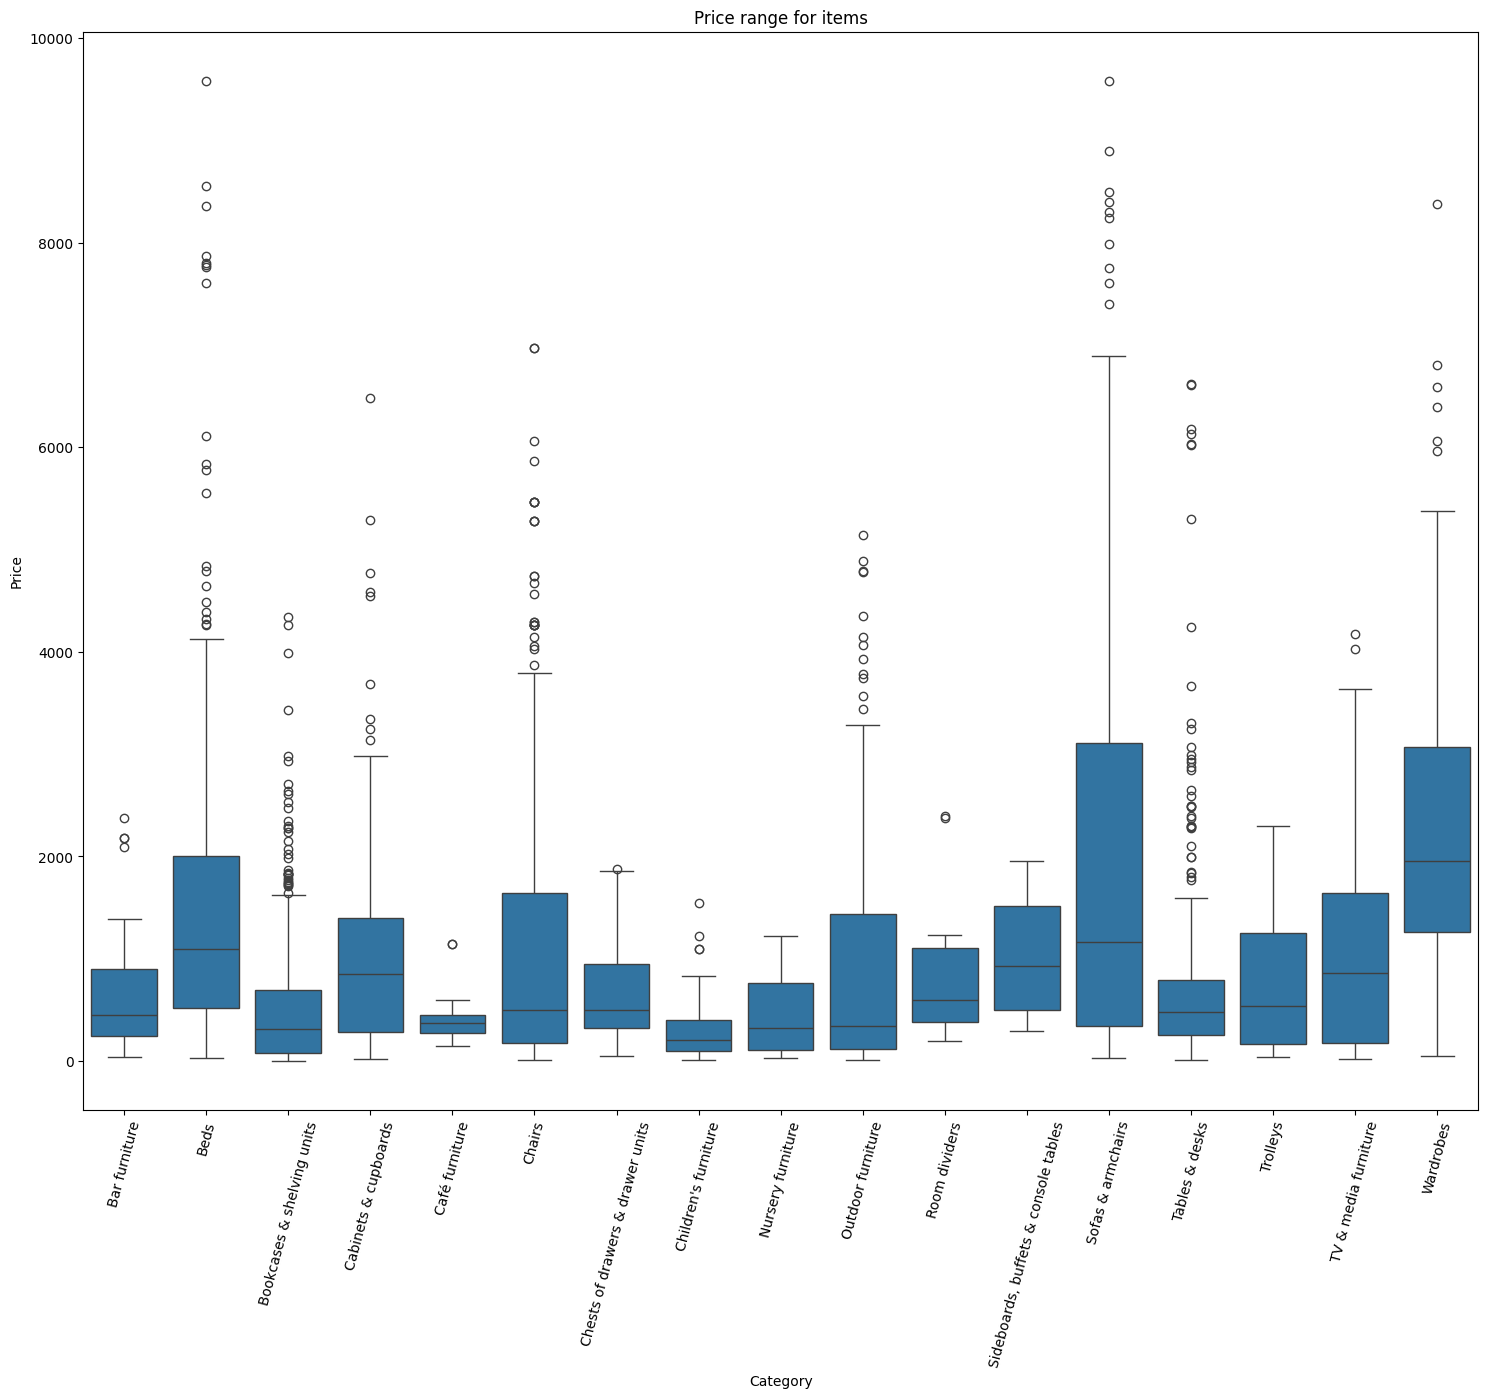

In [428]:
plt.figure(figsize=(18, 14))
sns.boxplot(x=df_furniture_clean['category'], y=df_furniture_clean['price'], data=df_furniture_clean)
plt.title('Price range for items')
plt.xlabel('Category')
plt.ylabel('Price')
plt.xticks(rotation=75)
plt.show()

Visualization of the scope of items in each category that IKEA has got at the moment. Here we can find the information of categories that have the biggest number of products in IKEA.

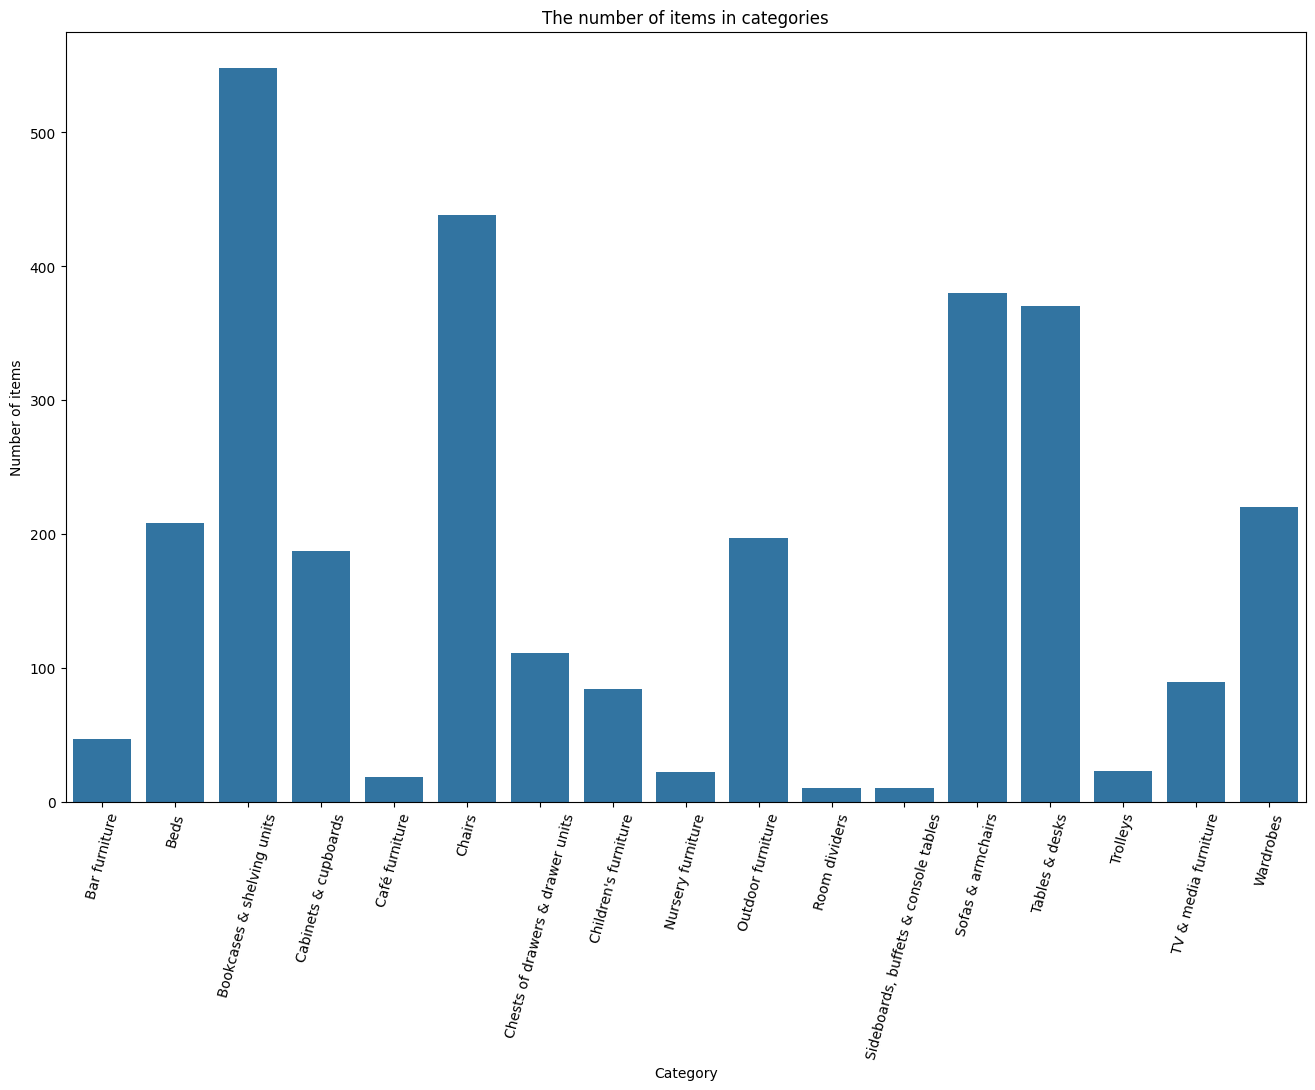

In [429]:
df_furn=df_furniture_clean['category'].value_counts()

plt.figure(figsize=(16,10))
sns.countplot(x=df_furniture_clean['category'], data=df_furniture_clean)
plt.title('The number of items in categories')
plt.xlabel('Category')
plt.ylabel('Number of items')
plt.xticks(rotation=75)
plt.show();

The median for the price in each category. It is obvious that Wardrobes, Sofas and Beds enjoy the most expensive goods in our data set.

In [430]:
df_price=df_furniture_clean.groupby('category')['price'].mean()
print(df_price)


category
Bar furniture                            679.553191
Beds                                    1647.432692
Bookcases & shelving units               519.416058
Cabinets & cupboards                    1044.823529
Café furniture                           426.722222
Chairs                                  1097.124658
Chests of drawers & drawer units         657.490991
Children's furniture                     286.178571
Nursery furniture                        431.772727
Outdoor furniture                        919.759391
Room dividers                            912.600000
Sideboards, buffets & console tables    1013.000000
Sofas & armchairs                       1968.160526
TV & media furniture                    1045.651685
Tables & desks                           760.129730
Trolleys                                 748.869565
Wardrobes                               2249.015909
Name: price, dtype: float64


The visualization below shows the difference between the prices of ten biggest furniture categories in IKEA.

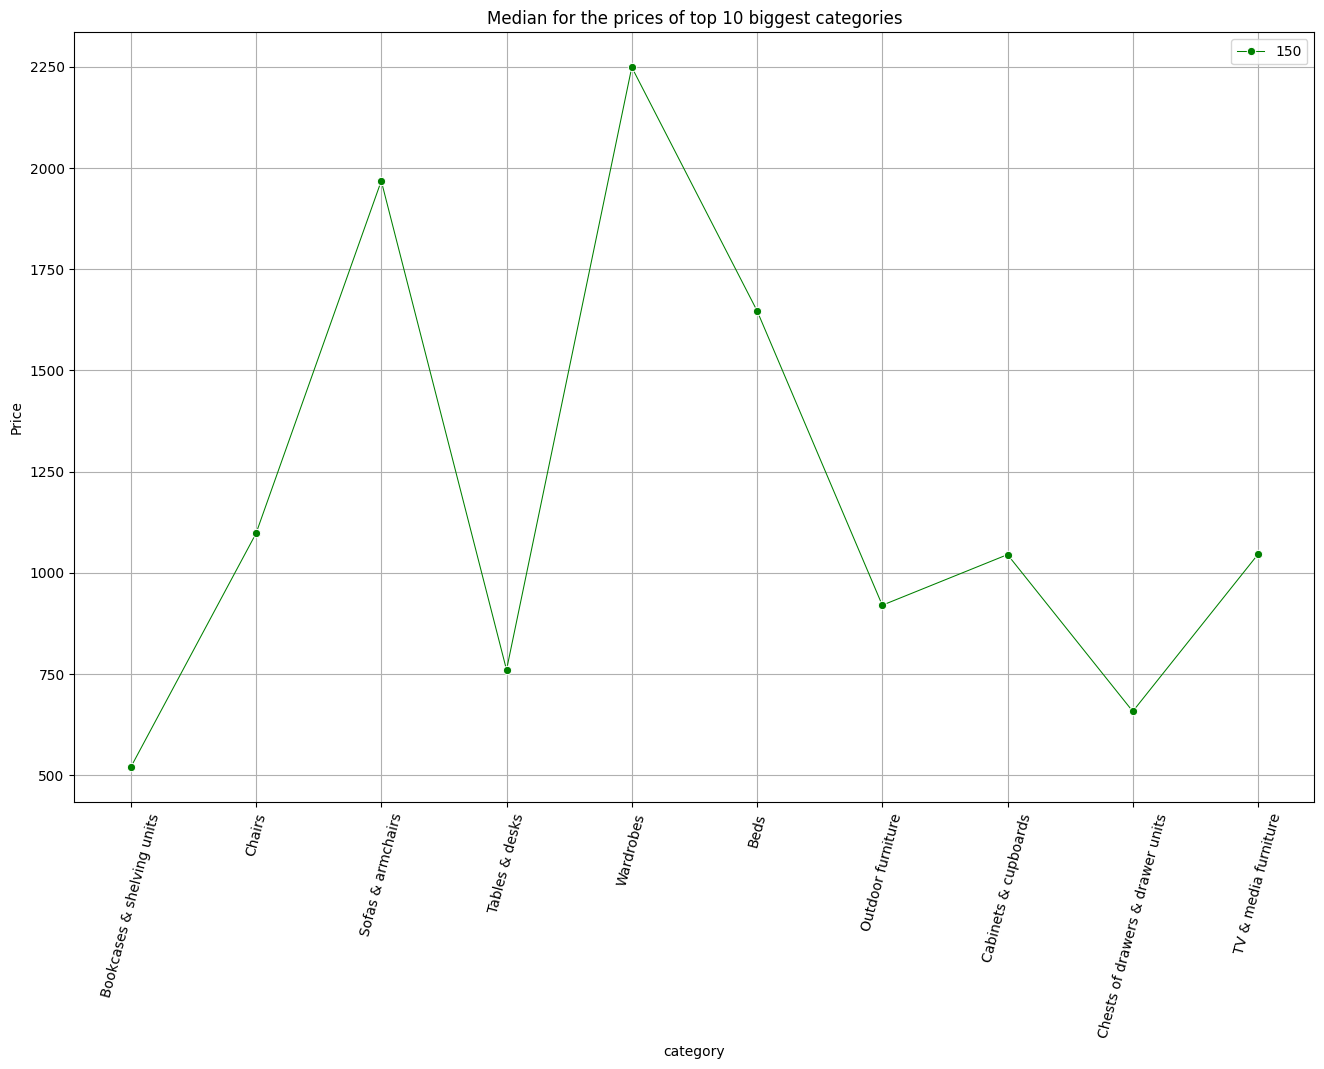

In [431]:
furn10=df_furn.head(10).sort_values(ascending=False)
furn10=furn10.rename_axis('category').reset_index()
df_furn10=pd.merge(furn10, df_price, on = 'category')
df_furn10=pd.DataFrame(df_furn10)

plt.figure(figsize=(16,10))
sns.lineplot(data=df_furn10, x='category', y='price',marker='o', size=150, color='green')
plt.title('Median for the prices of top 10 biggest categories')
plt.ylabel('Price')
plt.xticks(rotation=75)
plt.grid(True)
plt.show()

The visualization below demonstrates in what price segments the designers of the most expensive category of wardrobes are working in.

                                             designer   category   price
0   Andreas Fredriksson/Ehlén Johansson/IKEA of Sw...  Wardrobes  3885.0
2   Andreas Fredriksson/Ehlén Johansson/IKEA of Sw...  Wardrobes  3115.0
4      Ebba Strandmark/Ehlén Johansson/IKEA of Sweden  Wardrobes  5260.0
5      Ebba Strandmark/Ehlén Johansson/IKEA of Sweden  Wardrobes   665.0
6      Ebba Strandmark/Ehlén Johansson/IKEA of Sweden  Wardrobes  2415.0
7      Ebba Strandmark/Ehlén Johansson/IKEA of Sweden  Wardrobes  4685.0
8      Ebba Strandmark/Ehlén Johansson/IKEA of Sweden  Wardrobes  2580.0
9      Ebba Strandmark/Ehlén Johansson/IKEA of Sweden  Wardrobes  5240.0
10     Ebba Strandmark/Ehlén Johansson/IKEA of Sweden  Wardrobes  3110.0
11     Ebba Strandmark/Ehlén Johansson/IKEA of Sweden  Wardrobes  3500.0
12  Ebba Strandmark/Ehlén Johansson/IKEA of Sweden...  Wardrobes  6065.0
13  Ebba Strandmark/Ehlén Johansson/IKEA of Sweden...  Wardrobes  3190.0
14  Ebba Strandmark/Ehlén Johansson/IKEA of Sweden.

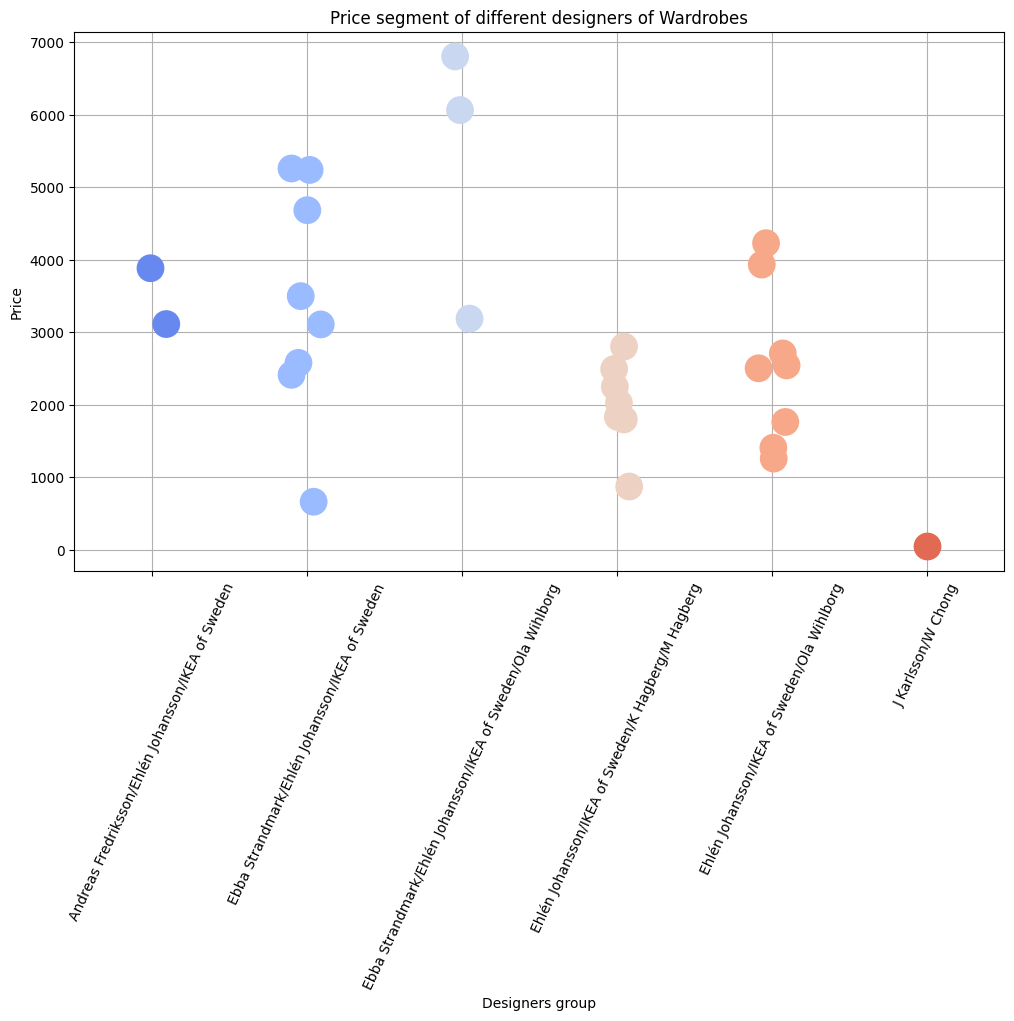

In [432]:
df_result = df_furniture_clean.groupby('designer')['category'] \
    .apply(lambda x: ', '.join(sorted(x.unique()))) \
    .reset_index()

df_result.columns = ['designer', 'category']
df_result

wardrobe_designer=df_result[df_result['category'] == 'Wardrobes']['designer']
unique_wardrobe_designers = wardrobe_designer[~wardrobe_designer.isin(df_result[df_result['category'] != 'Wardrobes']['designer'])
].unique()
unique_wardrobe_designers=pd.DataFrame(unique_wardrobe_designers, columns=['designer'])
unique_wardrobe_designers=pd.merge(unique_wardrobe_designers, df_result, on='designer')
unique_wardrobe_designers=unique_wardrobe_designers.merge(df_furniture_clean[['designer', 'category','price']], on =['designer', 'category'], how='left')
unique_wardrobe_designers=unique_wardrobe_designers.drop_duplicates()
print(unique_wardrobe_designers)

plt.figure(figsize=(12,7))
sns.stripplot(x='designer',y='price', data=unique_wardrobe_designers, jitter=True, size=20, palette="coolwarm")

plt.title('Price segment of different designers of Wardrobes')
plt.xlabel('Designers group')
plt.ylabel('Price')
plt.xticks(rotation=65)
plt.grid(True)
plt.show()


The visualization below shows the number of items developed by top 10 most active designers and designers collaborations in different categories.

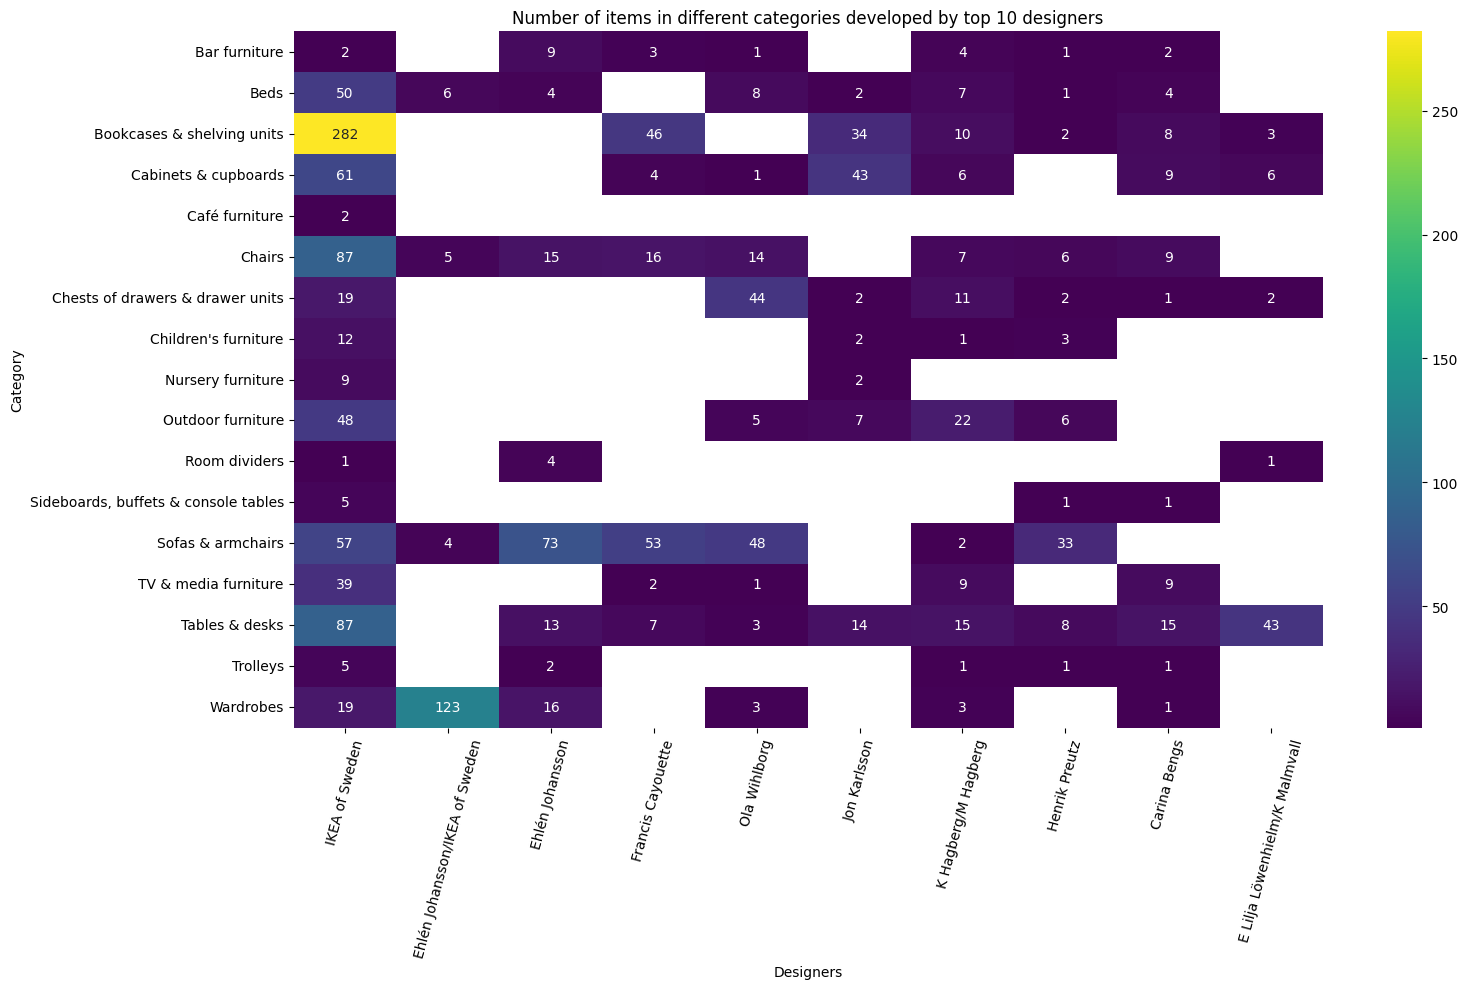

In [433]:
items_design = pd.pivot_table(df_furniture_clean,
                                         index='category',
                                         columns='designer',
                                         values='item_id',
                                         aggfunc='count',
                                         fill_value=0)

top_10_design = items_design.sum().nlargest(10).index

items_design10=items_design[top_10_design]

items_design10

plt.figure(figsize=(16, 10))
sns.heatmap(items_design10, cmap='viridis', annot=True, fmt='d', mask=(items_design10 == 0))
plt.title('Number of items in different categories developed by top 10 designers')
plt.xlabel('Designers')
plt.ylabel('Category')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


The visualization of correlation between furniture parameters and the price of items, after removing all items with no information in parameters (unfortunately, we can't apply here mode or median, taking into account that it can make some data nonsense.)



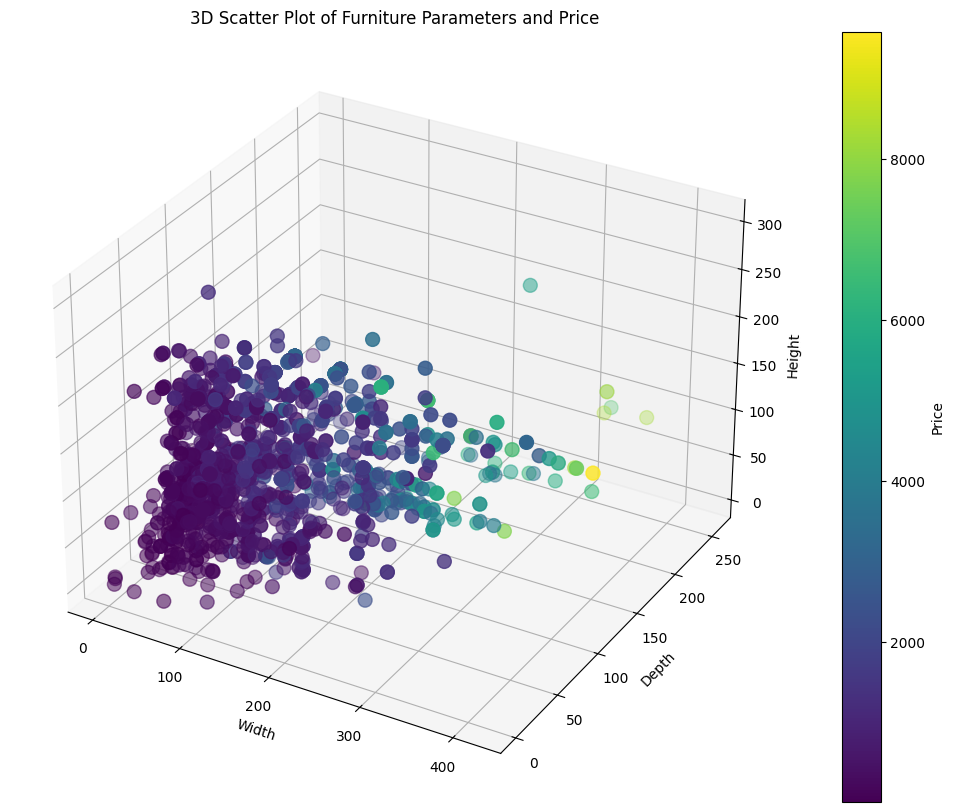

In [434]:
df_furniture_clean_param=df_furniture_clean.dropna(subset=['depth', 'width', 'height'])

from mpl_toolkits.mplot3d import Axes3D

fig=plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(df_furniture_clean_param['width'], df_furniture_clean_param['depth'], df_furniture_clean_param['height'], c=df_furniture_clean_param['price'], cmap='viridis', s=100)

ax.set_xlabel('Width')
ax.set_ylabel('Depth')
ax.set_zlabel('Height')
plt.colorbar(sc, label="Price")
plt.title("3D Scatter Plot of Furniture Parameters and Price")
plt.show()



The visualization of number of items in different categoris with and without color.

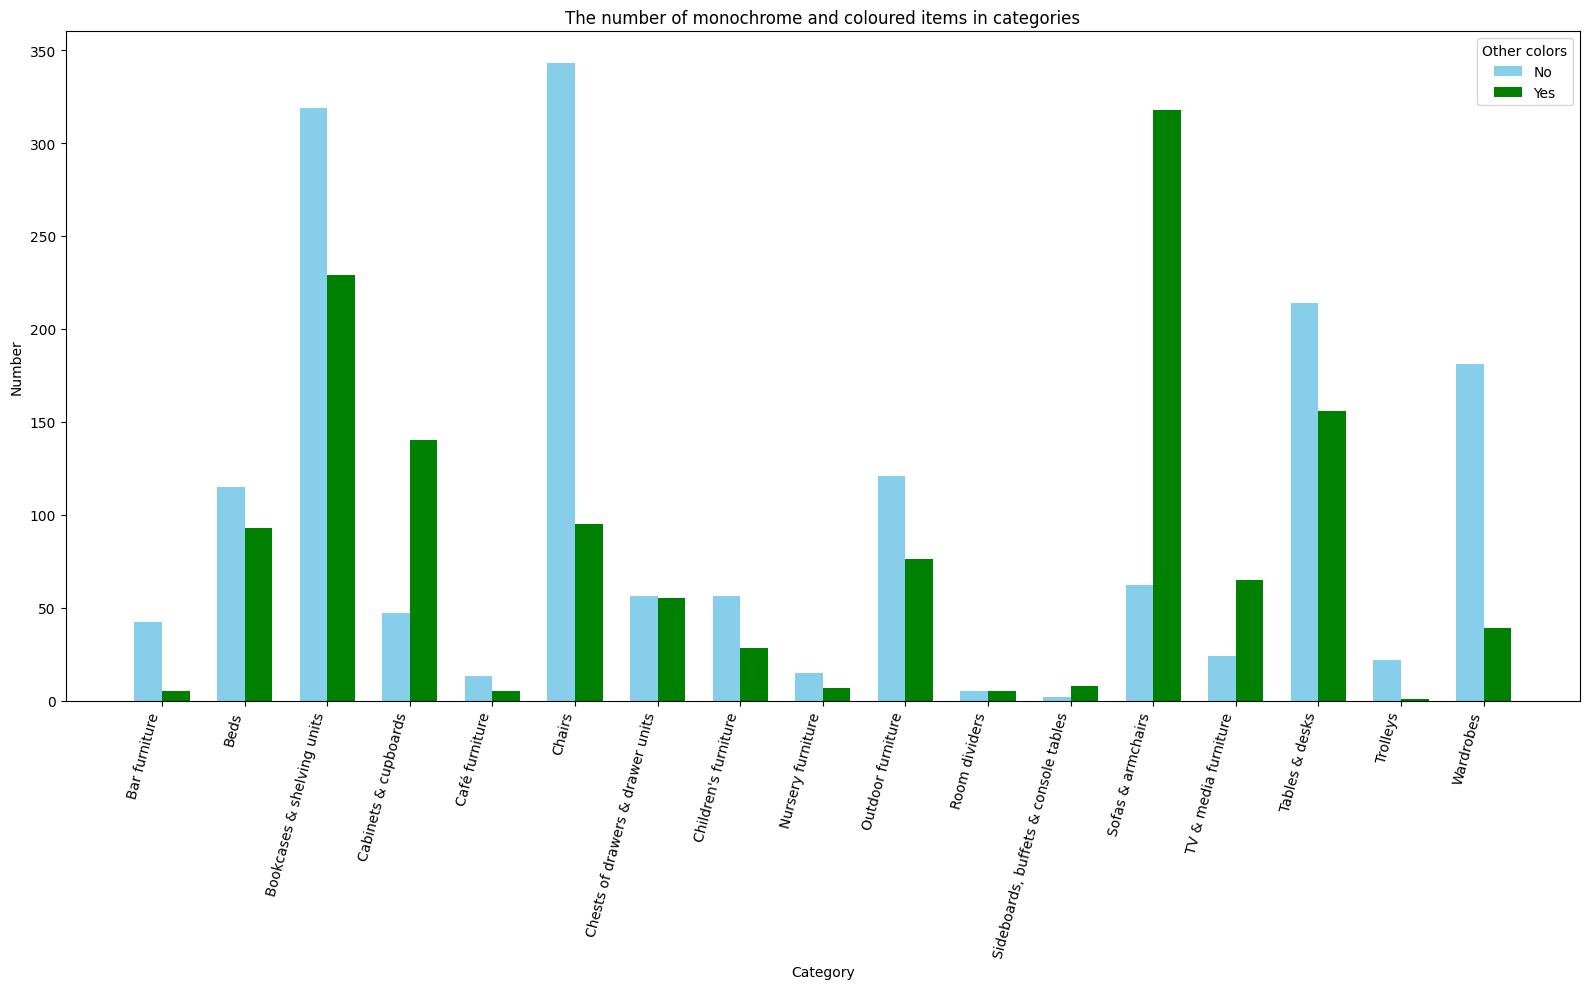

In [435]:
df_colors=df_furniture_clean.groupby('category')['other_colors'].value_counts()
df_colors=pd.DataFrame(df_colors, columns=['count'])
df_colors = df_colors.reset_index()


pivot_df = df_colors.pivot(index='category', columns='other_colors', values='count').reset_index()
df_colors

categories = pivot_df['category']
num_categories = len(categories)
gap = 0.5
x = [i * (1 + gap) for i in range(num_categories)]
bar_width = 0.5

plt.figure(figsize=(16,10))

plt.bar([pos - bar_width/2 for pos in x], pivot_df['No'], width=bar_width, label='No', color='skyblue')
plt.bar([pos + bar_width/2 for pos in x], pivot_df['Yes'], width=bar_width, label='Yes', color='green')

plt.xticks(x, categories, rotation=75, ha="right")
plt.ylabel('Number')
plt.xlabel('Category')
plt.title('The number of monochrome and coloured items in categories')
plt.legend(title='Other colors')
plt.tight_layout()
plt.show()

The visualization of median for price in different categories, depending if they are coloured or not.

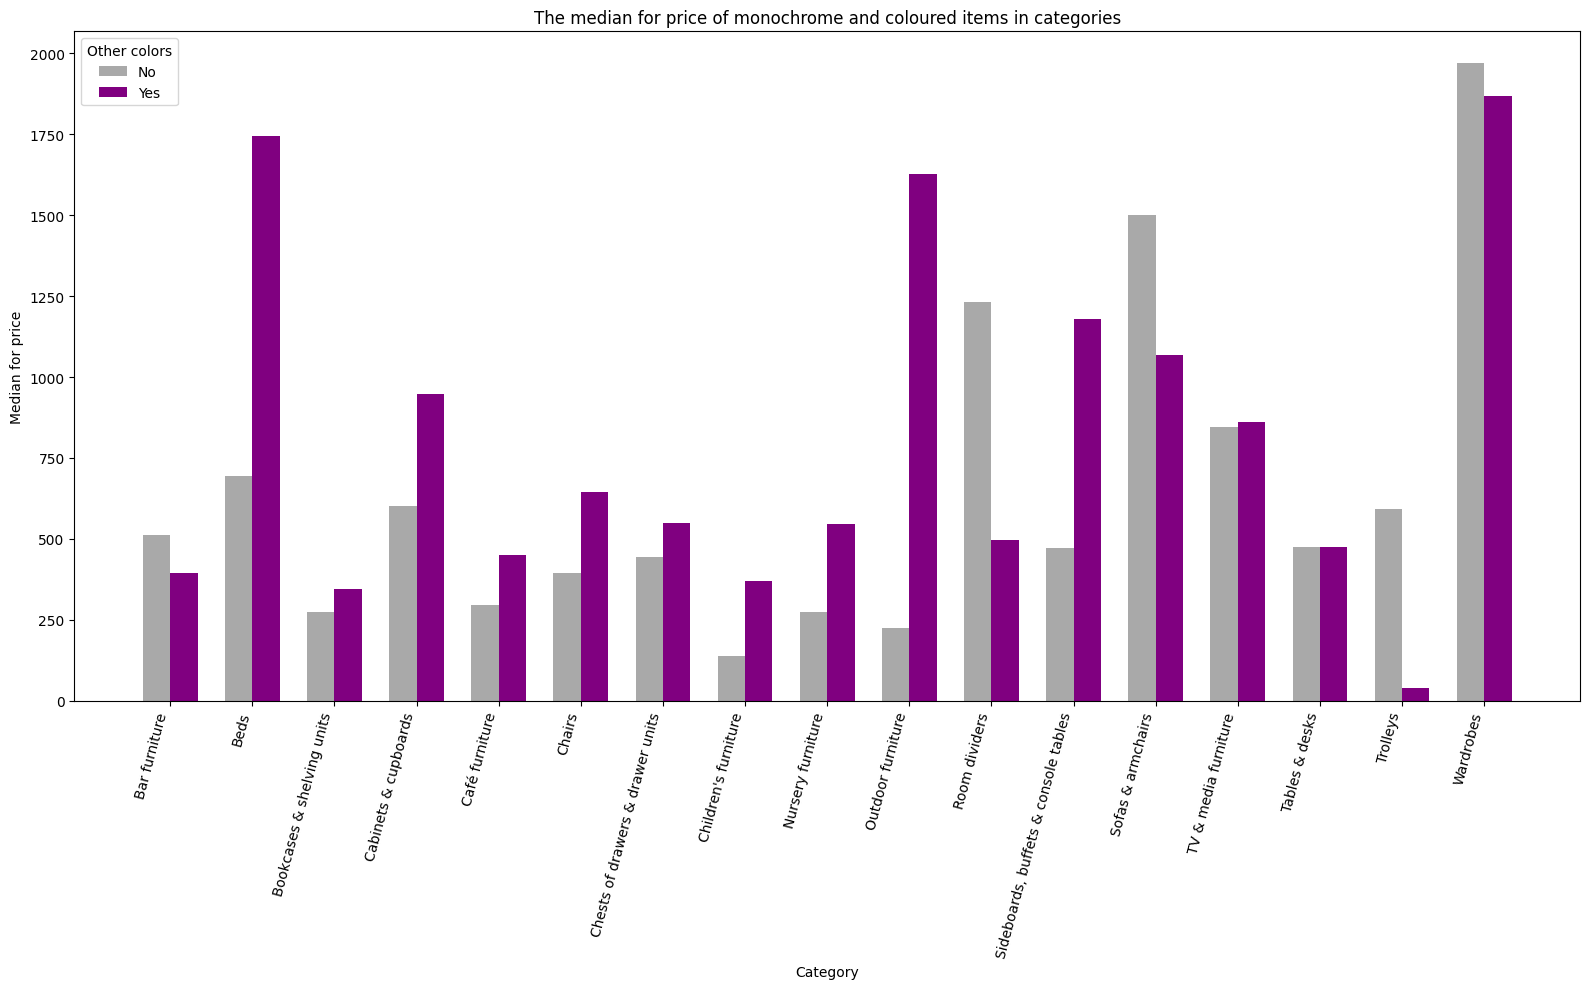

In [436]:
df_colors2=df_furniture_clean.groupby(['category', 'other_colors'])['price'].median()
df_colors2=pd.DataFrame(df_colors2)
df_colors2=df_colors2.reset_index()

pivot_df2 = df_colors2.pivot(index='category', columns='other_colors', values='price').reset_index()
df_colors2

categorie = pivot_df2['category']
num_categorie = len(categorie)
gap = 0.5
x = [i * (1 + gap) for i in range(num_categorie)]
bar_width = 0.5

plt.figure(figsize=(16,10))

plt.bar([pos - bar_width/2 for pos in x], pivot_df2['No'], width=bar_width, label='No', color='darkgray')
plt.bar([pos + bar_width/2 for pos in x], pivot_df2['Yes'], width=bar_width, label='Yes', color='purple')

plt.xticks(x, categories, rotation=75, ha="right")
plt.ylabel('Median for price')
plt.xlabel('Category')
plt.title('The median for price of monochrome and coloured items in categories')
plt.legend(title='Other colors')
plt.tight_layout()
plt.show()


The visualization of volumes of items, available online and offline.

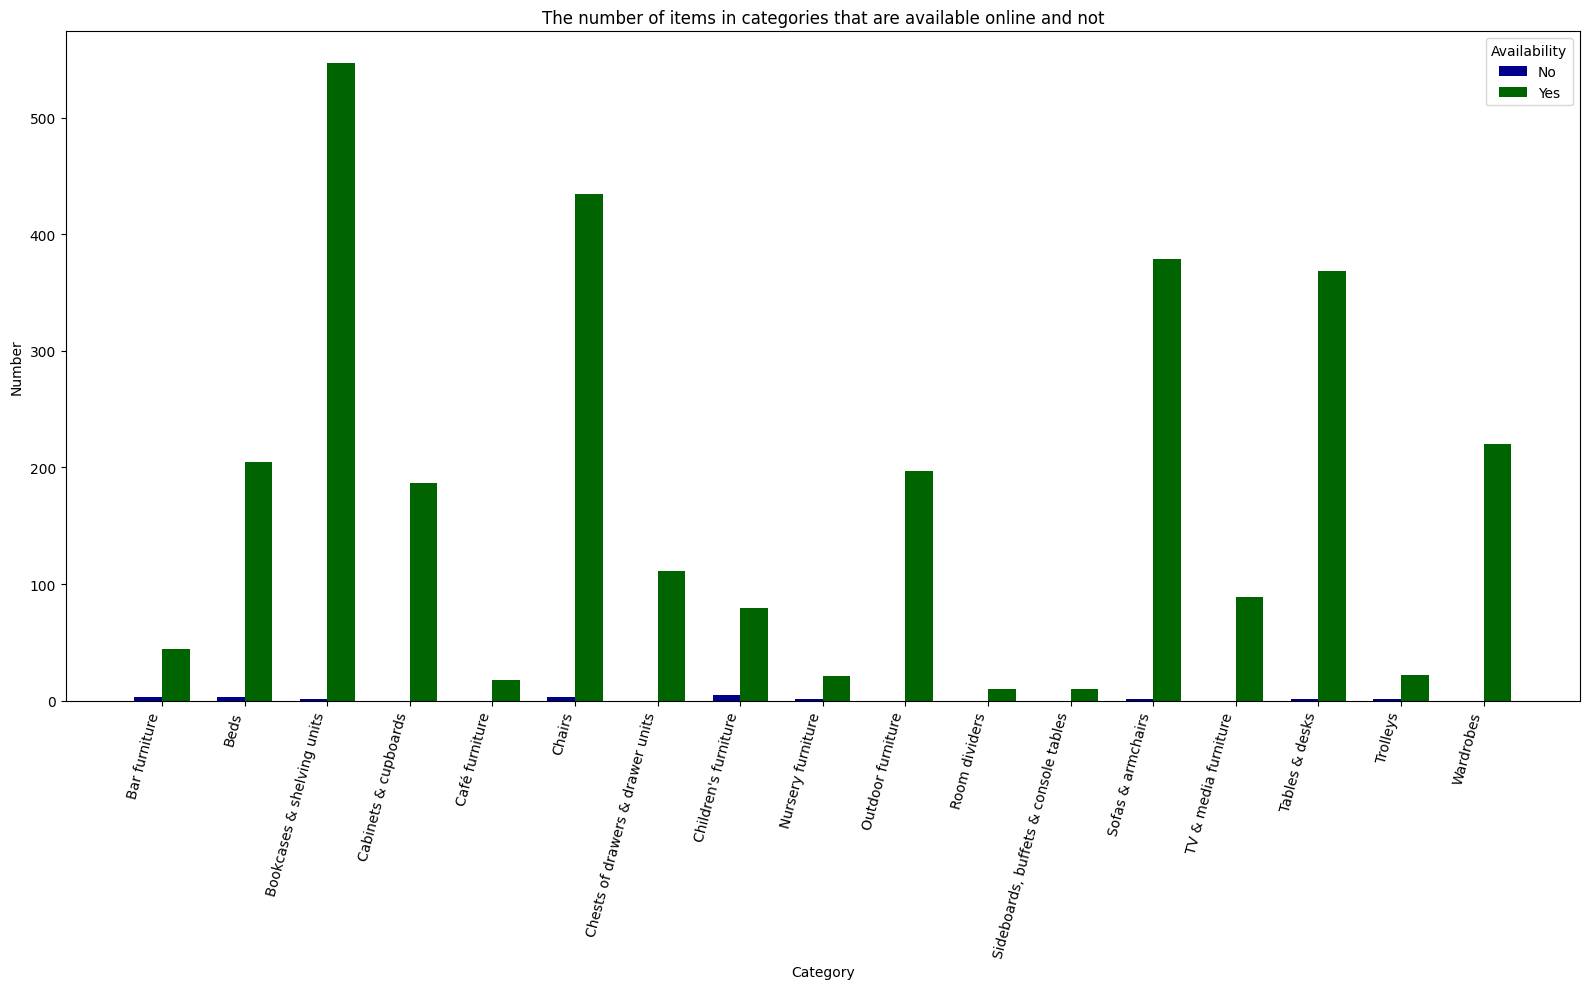

In [437]:
df_virtual=df_furniture_clean.groupby('category')['sellable_online'].value_counts()
df_virtual=pd.DataFrame(df_virtual, columns=['count'])
df_virtual = df_virtual.reset_index()
df_virtual

pivot_dfv = df_virtual.pivot(index='category', columns='sellable_online', values='count').reset_index()


categories = pivot_dfv['category']
num_categories = len(categories)
gap = 0.5
x = [i * (1 + gap) for i in range(num_categories)]
bar_width = 0.5

plt.figure(figsize=(16,10))

plt.bar([pos - bar_width/2 for pos in x], pivot_dfv[False], width=bar_width, label='No', color='darkblue')
plt.bar([pos + bar_width/2 for pos in x], pivot_dfv[True], width=bar_width, label='Yes', color='darkgreen')

plt.xticks(x, categories, rotation=75, ha="right")
plt.ylabel('Number')
plt.xlabel('Category')
plt.title('The number of items in categories that are available online and not')
plt.legend(title='Availability')
plt.tight_layout()
plt.show()

The visualization of difference between the prices for items that are available online and those that are not in different categories.

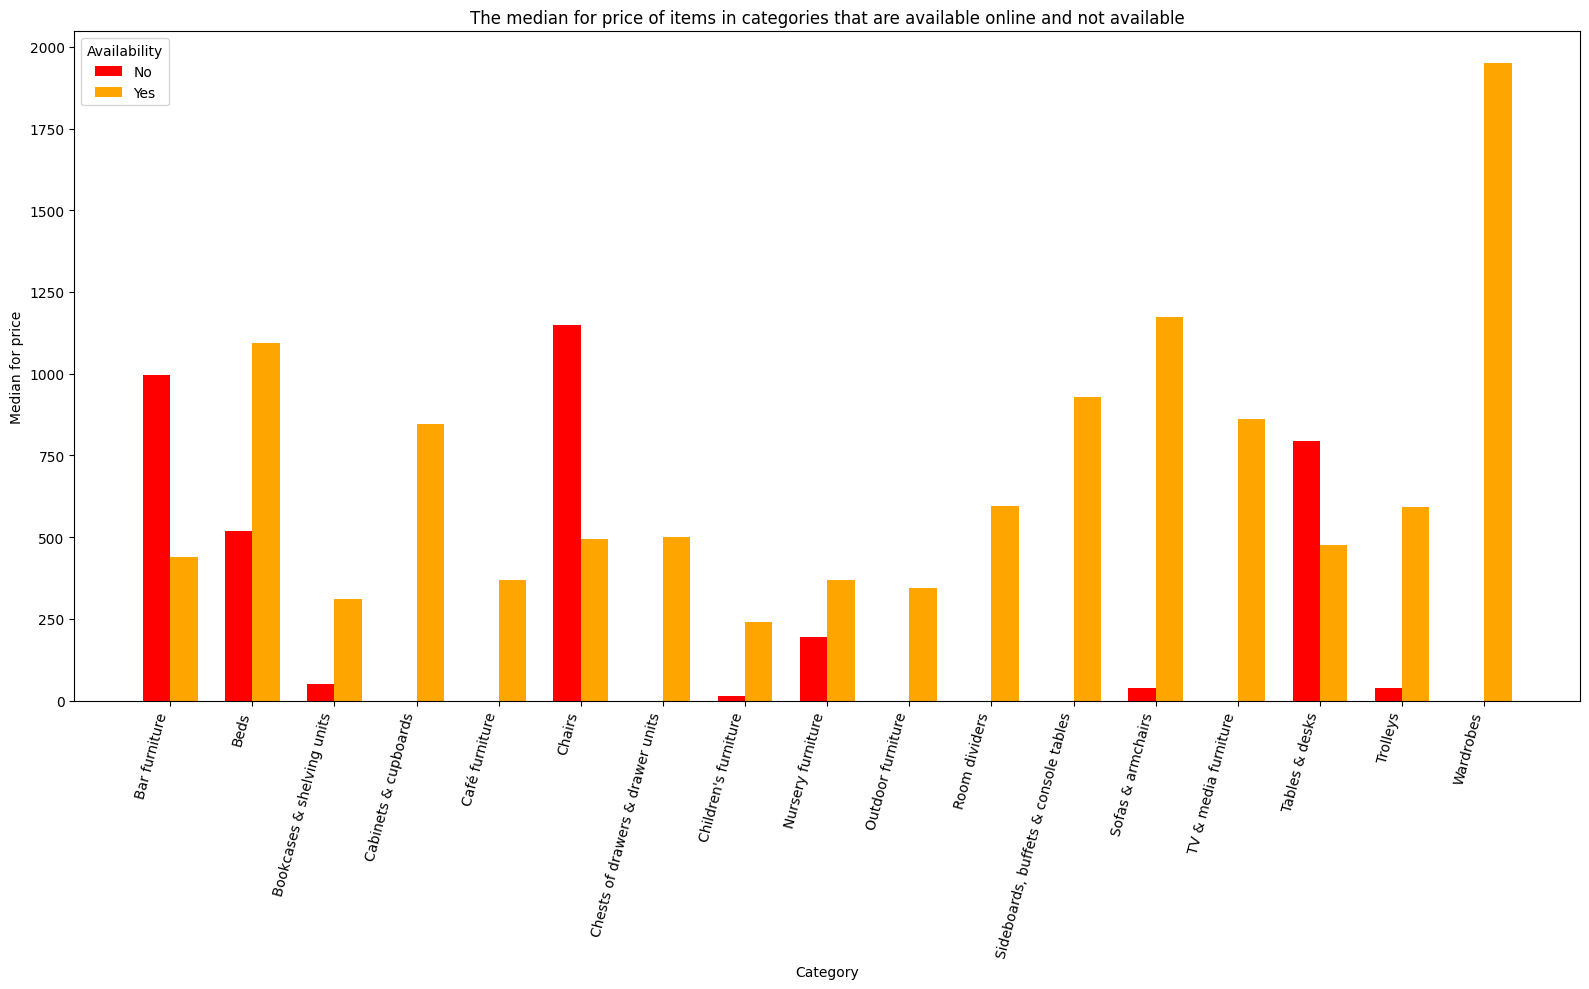

In [438]:
df_virtual2=df_furniture_clean.groupby(['category', 'sellable_online'])['price'].median()
df_virtual2=pd.DataFrame(df_virtual2)
df_virtual2=df_virtual2.reset_index()

pivot_dfv2 = df_virtual2.pivot(index='category', columns='sellable_online', values='price').reset_index()
df_virtual2

categorie = pivot_dfv2['category']
num_categorie = len(categorie)
gap = 0.5
x = [i * (1 + gap) for i in range(num_categorie)]
bar_width = 0.5

plt.figure(figsize=(16,10))

plt.bar([pos - bar_width/2 for pos in x], pivot_dfv2[False], width=bar_width, label='No', color='red')
plt.bar([pos + bar_width/2 for pos in x], pivot_dfv2[True], width=bar_width, label='Yes', color='orange')

plt.xticks(x, categories, rotation=75, ha="right")
plt.ylabel('Median for price')
plt.xlabel('Category')
plt.title('The median for price of items in categories that are available online and not available')
plt.legend(title='Availability')
plt.tight_layout()
plt.show()

The visualization of the difference between old and new prices in different categories. We are taking an average price because median will not be demonstrative especially for old prices where we do not have a lot of data. By the graphics we can say about brand new goods in the case we don't have the old priceas well as about negative dynamic of prices fell in all categories.

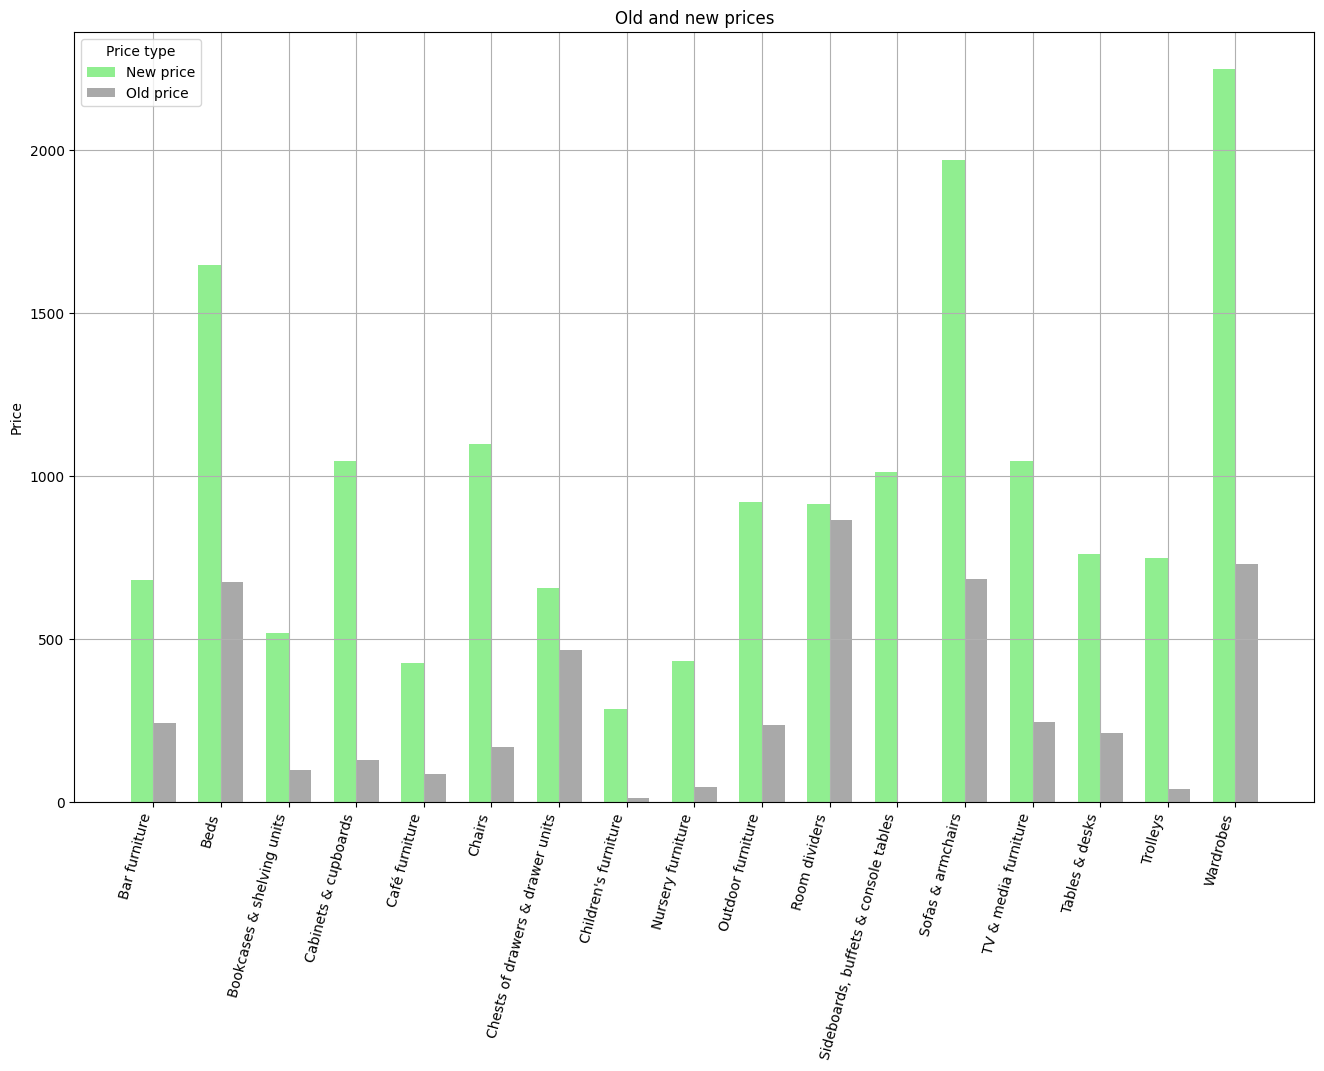

In [443]:
df_prices=df_furniture_clean.groupby(['category'])[['price', 'old_price']].mean()
df_prices=pd.DataFrame(df_prices)
df_prices=df_prices.reset_index()
df_prices

df_prices_melted = pd.melt(df_prices, id_vars=['category'], value_vars=['price', 'old_price'], var_name='price_type', value_name='price_value')

pivot_prices = df_prices_melted.pivot(index='category', columns='price_type', values='price_value').reset_index()


categorie = pivot_prices['category']
num_categorie = len(categorie)
gap = 0.5
x = [i * (1 + gap) for i in range(num_categorie)]
bar_width = 0.5

plt.figure(figsize=(16,10))

plt.bar([pos - bar_width/2 for pos in x], pivot_prices['price'], width=bar_width, label='New price', color='lightgreen')
plt.bar([pos + bar_width/2 for pos in x], pivot_prices['old_price'], width=bar_width, label='Old price', color='darkgray')

plt.xticks(x, categorie, rotation=75, ha="right")
plt.title('Old and new prices')
plt.ylabel('Price')
plt.xticks(rotation=75)
plt.legend(title='Price type')
plt.grid(True)
plt.show()


**Hypothesis I**

Hypothesis 0 -> furniture items by IKEA of Sweden are cheaper than those by certain designers

Hypothesis 1 ->  furniture items by IKEA of Sweden are not cheaper than those by certain designers

In [444]:
from scipy.stats import ttest_ind

data = df_furniture_clean

ikea=df_furniture_clean[df_furniture_clean['designer'] == 'IKEA of Sweden']['price']
designers=df_furniture_clean[df_furniture_clean['designer']!='IKEA of Sweden']['price']

t_stat, p_value = ttest_ind(ikea, designers, equal_var=False)

print(f'T-statistic:{t_stat:.2f}')
print(f'P-value: {p_value:.2f}')
alpha=0.05

if p_value < alpha:
  print (f'Reject the null hypothesis: IKEA of Sweden furniture is not cheaper')

else:
  print(f'Fail to reject the null hypothesis: IKEA of Sweden furniture is cheaper.')

T-statistic:-19.06
P-value: 0.00
Reject the null hypothesis: IKEA of Sweden furniture is not cheaper


In [445]:
from scipy.stats import mannwhitneyu

m_stat, p_value = mannwhitneyu(ikea, designers, alternative='two-sided')

print(f'M-statistic:{t_stat:.2f}')
print(f'P-value: {p_value:.2f}')
alpha=0.05

if p_value < alpha:
  print (f'Reject the null hypothesis: IKEA of Sweden furniture is not cheaper')

else:
  print(f'Fail to reject the null hypothesis: IKEA of Sweden furniture is cheaper.')

M-statistic:-19.06
P-value: 0.00
Reject the null hypothesis: IKEA of Sweden furniture is not cheaper


In [446]:

tukey_results = pairwise_tukeyhsd(np.concatenate([ikea, designers]),
                                  np.concatenate([['ikea'] * len(ikea),
                                                  ['other_designers'] * len(designers)]))

print(tukey_results.summary())


     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
group1      group2     meandiff p-adj  lower    upper   reject
--------------------------------------------------------------
  ikea other_designers 778.3877   0.0 668.1222 888.6532   True
--------------------------------------------------------------


All three tests showed that there is no correlation between the price of the item and design by IKEA of Sweden. P_value of 0 for ttest and Mann-Whitney U test rejects the null-hypothesis completely while tukey test also shows 0 p_value.

In order to be sure in this result we are cleaning the data from wastes. That doesn't remove a lot of products but make the data a bit smoothier in some categories like Wardrobes and Sofas&armchairs.

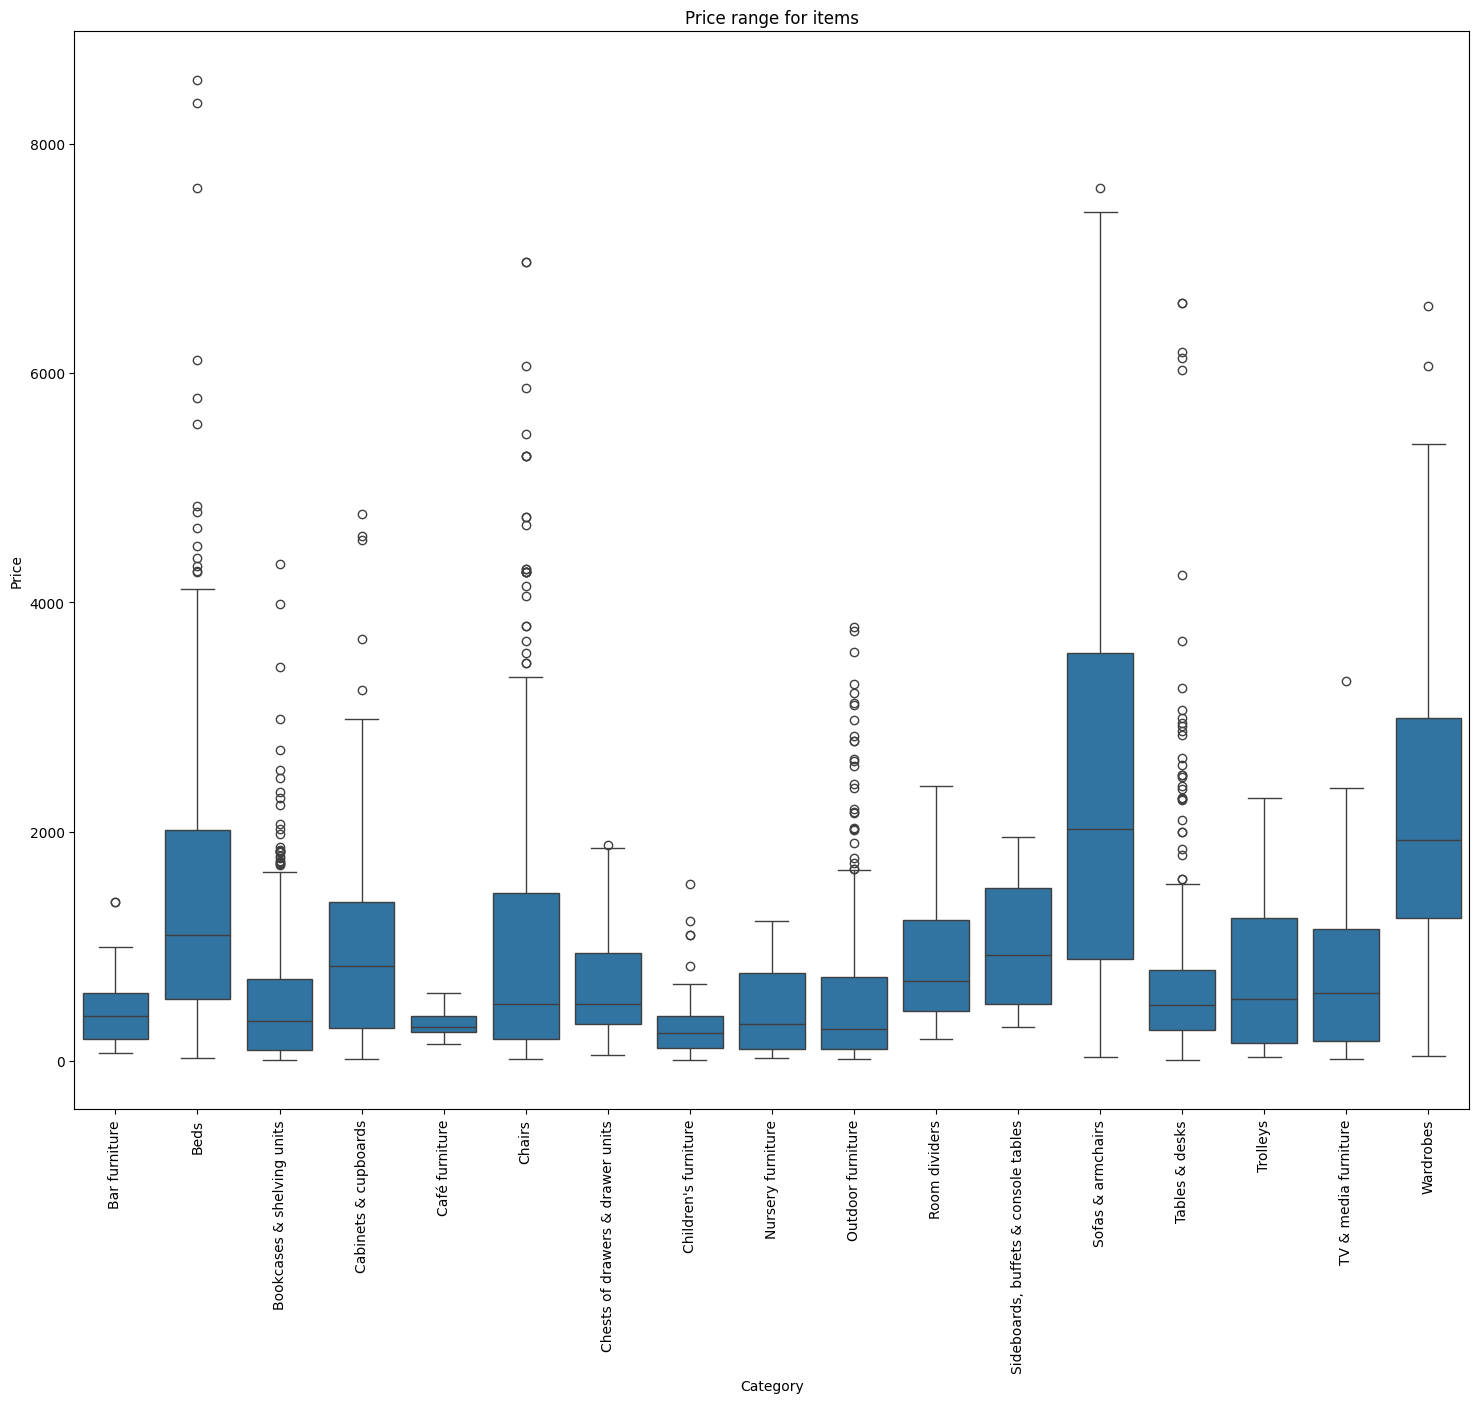

In [297]:
for feature in numerical_features:
   Q1=df_furniture_clean[feature].quantile(0.25)
   Q3=df_furniture_clean[feature].quantile(0.75)
   IQR=Q3-Q1

   lower_bound=Q1-1.5*IQR
   upper_bound =Q3+1.5*IQR

   df_furniture_clean2=df_furniture_clean[(df_furniture_clean[feature]>=lower_bound)&(df_furniture_clean[feature]<=upper_bound)]

plt.figure(figsize=(18, 14))
sns.boxplot(x=df_furniture_clean2['category'], y=df_furniture_clean2['price'], data=df_furniture_clean2)
plt.title('Price range for items')
plt.xlabel('Category')
plt.ylabel('Price')
plt.xticks(rotation=90)
plt.show()

Now we are conducting tests one more time. The result of rejecting null hypothesis is confirmed: p_value is still null, while T-statistic remains significantly negative.

In [447]:
data = df_furniture_clean2

ikea2=df_furniture_clean2[df_furniture_clean2['designer'] == 'IKEA of Sweden']['price']
designers2=df_furniture_clean2[df_furniture_clean2['designer']!='IKEA of Sweden']['price']

t_stat, p_value = ttest_ind(ikea2, designers2, equal_var=False)

print(f'T-statistic:{t_stat:.2f}')
print(f'P-value: {p_value:.2f}')
alpha=0.05

if p_value < alpha:
  print (f'Reject the null hypothesis: IKEA of Sweden furniture is not cheaper')

else:
  print(f'Fail to reject the null hypothesis: IKEA of Sweden furniture is cheaper.')

print('*'*50)

m_stat, p_value = mannwhitneyu(ikea2, designers2, alternative='two-sided')

print(f'M-statistic:{t_stat:.2f}')
print(f'P-value: {p_value:.2f}')
alpha=0.05

if p_value < alpha:
  print (f'Reject the null hypothesis: IKEA of Sweden furniture is not cheaper')

else:
  print(f'Fail to reject the null hypothesis: IKEA of Sweden furniture is cheaper.')


print('*'*50)
tukey_results2 = pairwise_tukeyhsd(np.concatenate([ikea2, designers2]),
                                  np.concatenate([['ikea'] * len(ikea2),
                                                  ['other_designers'] * len(designers2)]))

print(tukey_results.summary())


T-statistic:-16.36
P-value: 0.00
Reject the null hypothesis: IKEA of Sweden furniture is not cheaper
**************************************************
M-statistic:-16.36
P-value: 0.00
Reject the null hypothesis: IKEA of Sweden furniture is not cheaper
**************************************************
     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
group1      group2     meandiff p-adj  lower    upper   reject
--------------------------------------------------------------
  ikea other_designers 778.3877   0.0 668.1222 888.6532   True
--------------------------------------------------------------



**Hypothesis II**

Hypothesis 0 -> the size of category depends on the price

Hypothesis 1 ->  the size of category doesn't depend on the price

In other words we are considering if the number of the furniture items in different categories depend on their price.

In [448]:
from scipy.stats import spearmanr

df_furn2=df_furniture_clean['category'].value_counts()
df_price2=df_furniture_clean.groupby('category')['price'].mean()
data=pd.merge(df_furn2, df_price2, on = 'category')
data=pd.DataFrame(data)
print(data)

print('*'*50)

corr, p_value=spearmanr(data['count'], data['price'])
print(f"Spearman Correlation: {corr:.2f}")
print(f"P-Value: {p_value:.2f}")

alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis: There is no correlation between the average price and the category size.")
else:
    print("Fail to reject the null hypothesis:There is correlation between the average price and the category size.")

                                      count        price
category                                                
Bookcases & shelving units              548   519.416058
Chairs                                  438  1097.124658
Sofas & armchairs                       380  1968.160526
Tables & desks                          370   760.129730
Wardrobes                               220  2249.015909
Beds                                    208  1647.432692
Outdoor furniture                       197   919.759391
Cabinets & cupboards                    187  1044.823529
Chests of drawers & drawer units        111   657.490991
TV & media furniture                     89  1045.651685
Children's furniture                     84   286.178571
Bar furniture                            47   679.553191
Trolleys                                 23   748.869565
Nursery furniture                        22   431.772727
Café furniture                           18   426.722222
Sideboards, buffets & console t

Kendall correlation coefficient:0.29
P_value:0.11
Fail to reject the null hypothesis: There is correlation between the average price and the category size


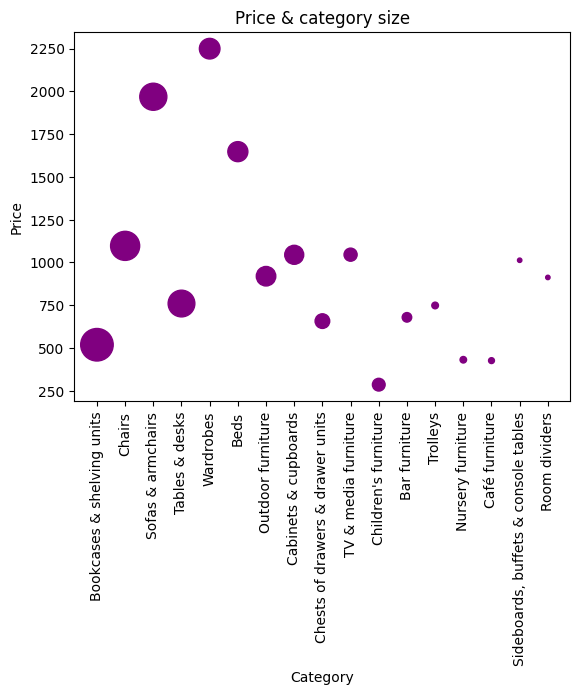

In [449]:
from scipy.stats import kendalltau

stat, p_value = kendalltau(data['count'], data['price'])
print(f'Kendall correlation coefficient:{stat:.2f}')
print(f'P_value:{p_value:.2f}')

alpha=0.05

if p_value < alpha:
  print(f'Reject the null hypothesis: There is no correlation between the average price and the caegory size')
else:
  print(f'Fail to reject the null hypothesis: There is correlation between the average price and the category size')

plt.scatter(data.index, data['price'], s=data['count'], color = 'purple')
plt.title('Price & category size')
plt.xlabel('Category')
plt.ylabel('Price')
plt.xticks(rotation=90)
plt.show()


According to the results of both tests and the visualization of the second one we can say that there is a correlation between the average price in the category and the number of items presented (the bigger number of products is, the bigger ball illustrates this product), though this correlation is very light. We have p_value that is nearly 0.2 that shows existence of slight relation between these dimensions.

**Machine Learning Part**

We are taking our cleaned data set and removing some columns that logically and due to our previous visualization have no influence on price.

In [454]:
df_data=df_furniture_clean2.drop(['item_id', 'short_description', 'sellable_online', 'other_colors'], axis=1)
df_data

,name,category,price,old_price,designer,depth,height,width
0,FREKVENS,Bar furniture,265.0,0,Nicholai Wiig Hansen,NaN,99.0,51.0
1,NORDVIKEN,Bar furniture,995.0,0,Francis Cayouette,NaN,105.0,80.0
3,STIG,Bar furniture,69.0,0,Henrik Preutz,50.0,100.0,60.0
4,NORBERG,Bar furniture,225.0,0,Marcus Arvonen,60.0,43.0,74.0
5,INGOLF,Bar furniture,345.0,0,Carina Bengs,45.0,91.0,40.0
...,...,...,...,...,...,...,...,...
2957,PAX / MEHAMN/AULI,Wardrobes,2045.0,0,Ehlén Johansson/IKEA of Sweden,66.0,236.0,200.0
2958,ELVARLI,Wardrobes,750.0,820,Ehlén Johansson,50.0,NaN,91.0
2959,ELVARLI,Wardrobes,1572.0,1755,Ehlén Johansson,50.0,NaN,135.0
2960,ELVARLI,Wardrobes,924.0,1050,Ehlén Johansson,50.0,NaN,175.0


We are dividing our data for the criteria and taking price as a target. We are creating the pipelines that enables to organize and standartize different kinds of data.

We have choosen four models to check their efficiency for training modal on our data set.

Taking our data and processing it within the function that defines the best model we are saving all methrics for four models in the data frame TestModels.Sorting them by R^2 we can say RandonForestRegressor is the most efficient as its coefficient is the closest to 1. And the indicator of 0.88 is a very good result, indicating that our model explains about 88% of the variance in the price variable across the dataset.
At the same time, taking into account that some prices in the data set are really small MAE of 229$ seems pretty huge difference between the real price and the predicted one. The same means for RMSE that is really big 404.
However, these indicators remain the best for RandomForestRegressor making this model the best choice among our variants for machine learning.

There are also one more visualization of price distribution and the graphics showing the metrics of models.

                             R^2      MAE     RMSE
Model                                             
RandomForestRegressor      0.883  229.118  403.844
GradientBoostingRegressor  0.824  329.838  494.718
DecisionTreeRegressor      0.806  325.163  519.319
LinearRegression           0.783  357.665  549.485


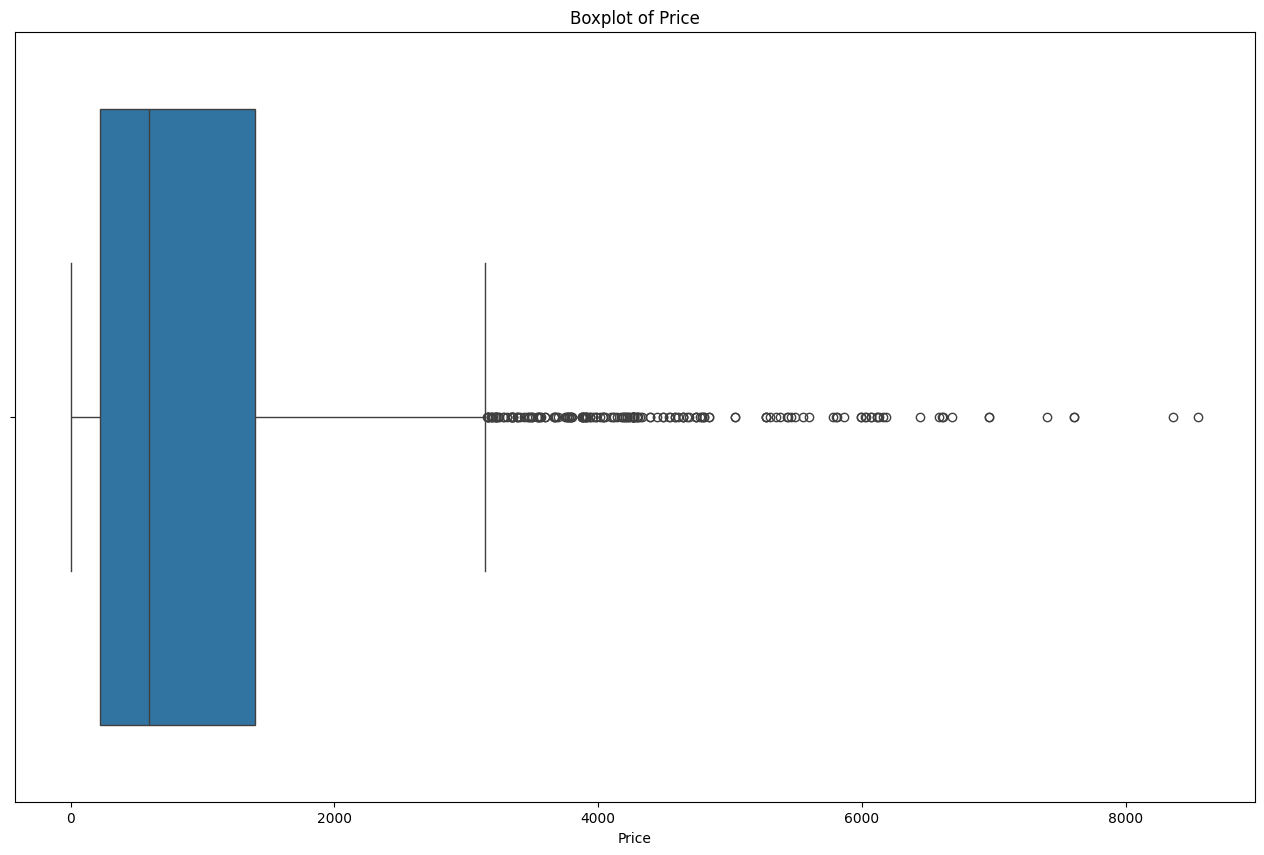

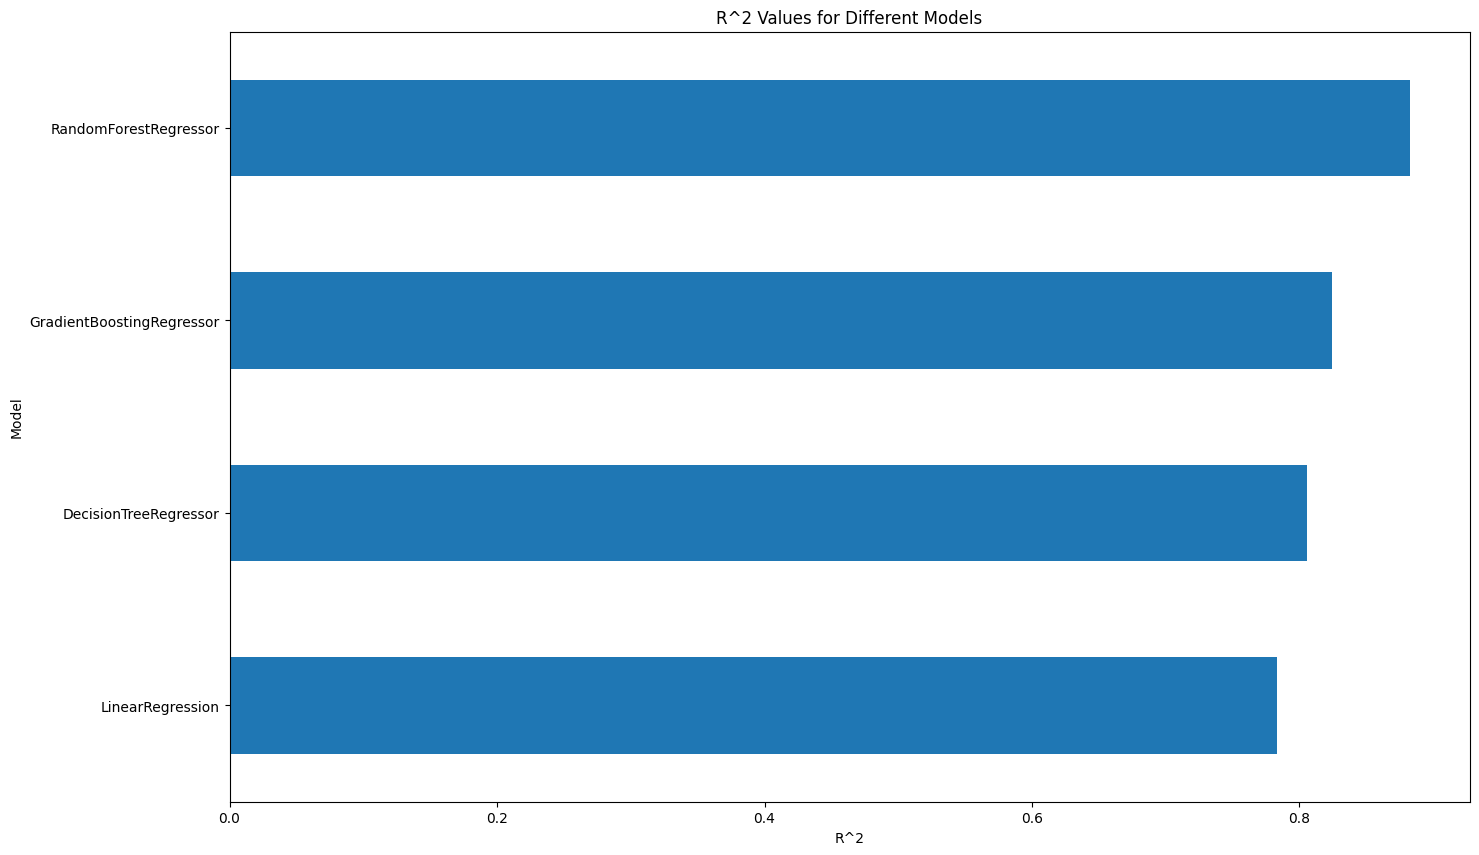

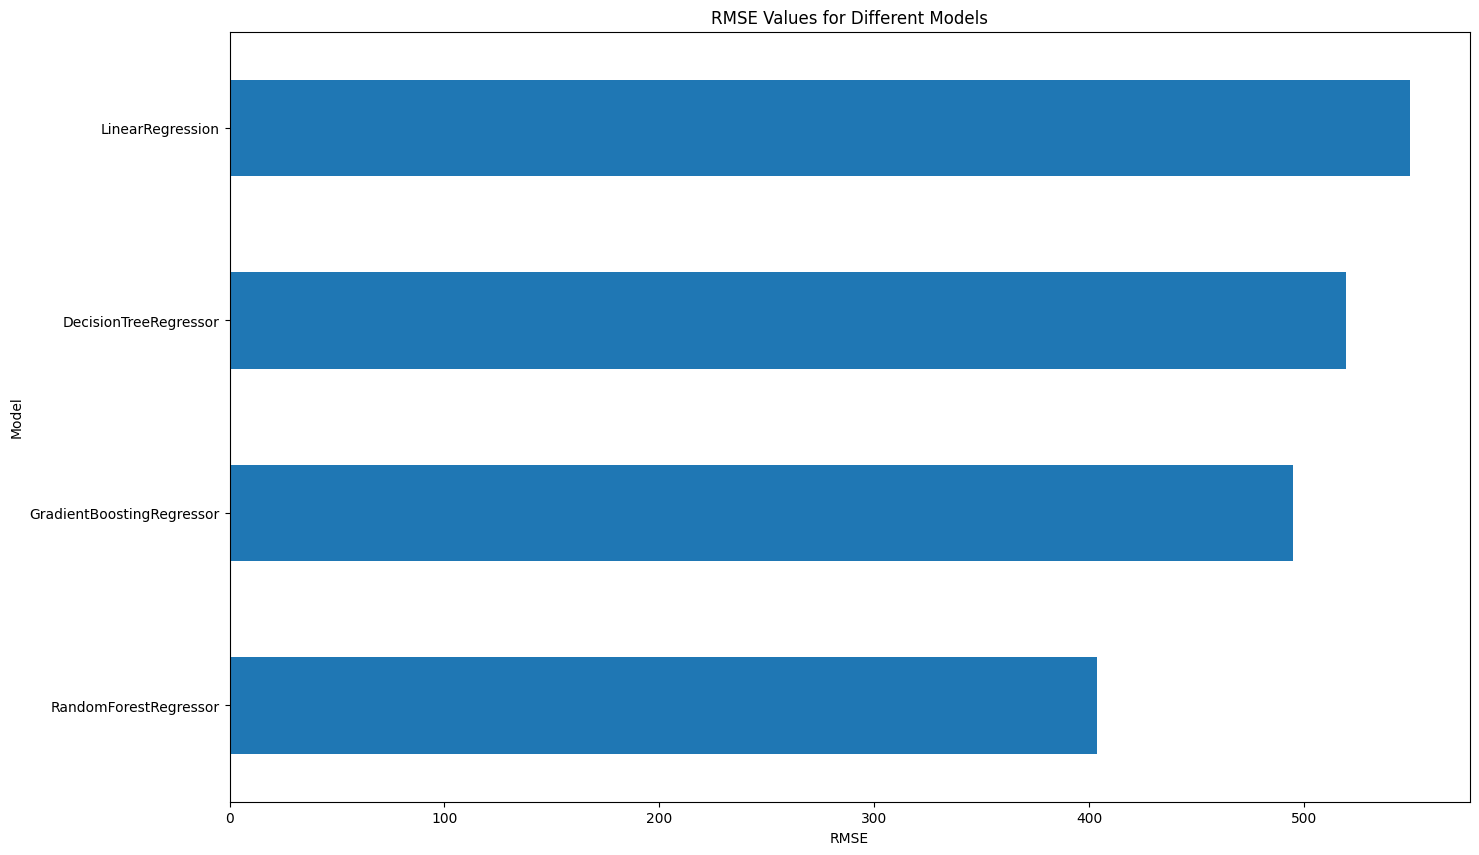

In [455]:
X = df_data[['name', 'category', 'old_price', 'designer', 'depth', 'width', 'height']]
y = df_data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def best_model (X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    models = [
        sk.linear_model.LinearRegression(),
        sk.tree.DecisionTreeRegressor(max_depth=10, random_state=42),
        RandomForestRegressor(random_state=42),
        GradientBoostingRegressor()
    ]

    TestModels = pd.DataFrame()
    result = {}
    tmp = {}


    for model in models:
        m = str(model)
        tmp['Model'] = m[:m.index('(')]

        col_trans = ColumnTransformer(
             transformers=[
                 ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                                   ('scaler', StandardScaler())]),
                  ['old_price','depth', 'width', 'height']),
                 ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                                   ('onehot', OneHotEncoder(handle_unknown='ignore'))]),
                  ['name','category', 'designer']),
             ],
           remainder='passthrough'
        )

        X_train_encoded = col_trans.fit_transform(X_train)
        X_test_encoded = col_trans.transform(X_test)

        model.fit(X_train_encoded, y_train)
        tmp['R^2'] = '{:.3f}'.format(model.score(X_test_encoded, y_test))
        tmp['MAE'] = '{:.3f}'.format(sk.metrics.mean_absolute_error(model.predict(X_test_encoded), y_test))
        tmp['RMSE'] = '{:.3f}'.format(np.sqrt(sk.metrics.mean_squared_error(model.predict(X_test_encoded), y_test)))

        TestModels = pd.concat([TestModels, pd.DataFrame([tmp])])

    TestModels.set_index('Model', inplace=True)
    result['model'] = TestModels
    result['X_train'] = X_train
    result['y_train'] = y_train
    result['X_test'] = X_test
    result['y_test'] = y_test
    return result

X1 = df_data[['name', 'category', 'old_price', 'designer', 'depth', 'width', 'height']]
y1 = df_data['price']

test1 = best_model(X1, y1)
test1['model'].sort_values(by='R^2', ascending=False)

print(test1['model'].sort_values(by='R^2', ascending=False))

plt.figure(figsize=(16, 10))
sns.boxplot(data=df_data, x='price')
plt.title('Boxplot of Price')
plt.xlabel('Price')
plt.show()

plt.figure(figsize=(16, 10))
test1['model']['R^2'] = test1['model']['R^2'].astype(float)
test1['model']['R^2'].sort_values().plot(kind='barh')
plt.title('R^2 Values for Different Models')
plt.xlabel('R^2')
plt.ylabel('Model')
plt.show()

plt.figure(figsize=(16, 10))
test1['model']['RMSE'] = test1['model']['RMSE'].astype(float)
test1['model']['RMSE'].sort_values().plot(kind='barh')
plt.title('RMSE Values for Different Models')
plt.xlabel('RMSE')
plt.ylabel('Model')
plt.show()

In order to find the most efficient parameters for models work we are using our primary data set, from which we are removing only data that is obviously (or due to our analysis above) has no influence on price. We are making a dictionary in which we save the results of two models we've already used - DecisionTreeRegressor and RandomForestRegressor but without optimization of parameters and with optimization of parameters with a help of GridSearchCV. In both cases we are observing the decrease of MSE that shows the way we can optimize our models. We can also say that the importance of parameters is higher for RandomForestRegressor that has shown as the most efficient in our previous test with cleaned data: MSE dropped here from 314266 to 267630.

In [456]:
df_data2=df_furniture.drop(['item_id', 'short_description', 'sellable_online', 'other_colors', ], axis=1)

X = df_data2[['name', 'category', 'old_price', 'designer', 'depth', 'width', 'height']]
y = df_data2['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

col_trans = ColumnTransformer(
    transformers=[
                ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())]),
                ['old_price', 'depth', 'width', 'height']),
                ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                                  ('onehot', OneHotEncoder(handle_unknown='ignore'))]),
                ['name', 'category', 'designer']),
             ],
          remainder='passthrough'
      )

X_train_encoded = col_trans.fit_transform(X_train)
X_test_encoded = col_trans.transform(X_test)

results2 = {
    'Model': [],
    'MSE without optimization': [],
    'Best Parameters': [],
    'MSE with optimization': []
}

def evaluate_model(model, param_grid, model_name):
  model.fit(X_train_encoded, y_train)
  y_pred=model.predict(X_test_encoded)
  mse=mean_squared_error(y_test, y_pred)

  grid_search=GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
  grid_search.fit(X_train_encoded, y_train)
  best_params=grid_search.best_params_
  best_mse=-grid_search.best_score_

  results2['Model'].append(model_name)
  results2['MSE without optimization'].append(mse)
  results2['Best Parameters'].append(best_params)
  results2['MSE with optimization'].append(best_mse)

param_grid_tree = {
    'max_depth':[5, 10, 25, 50],
    'min_samples_split':[2, 5, 10]
}
evaluate_model(DecisionTreeRegressor(), param_grid_tree, 'Decesion Tree')

param_grid_forest = {
    'n_estimators':[20, 50, 100],
    'max_depth':[10, 20, 30, 45],
    'min_samples_split':[2, 5, 10]
}
evaluate_model(RandomForestRegressor(), param_grid_forest, 'Random Forest')

results_df2 = pd.DataFrame(results2)
results_df2



,Model,MSE without optimization,Best Parameters,MSE with optimization
0,Decesion Tree,388129.100225,"{'max_depth': 50, 'min_samples_split': 10}",352013.517826
1,Random Forest,314266.474505,"{'max_depth': 45, 'min_samples_split': 2, 'n_e...",267630.864424


RandomForestRegressor with optimized parameters showed good results in all 5 iterations during cross-validation.
The model  performs consistently well across all the folds, reaching factually 90% of efficiency in one of iterations. A mean R^2 score made up of approximately 0.854

In [319]:
X = df_data2[['name', 'category', 'old_price', 'designer', 'depth', 'width', 'height']]
y = df_data2['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

col_trans2 = ColumnTransformer(
    transformers=[
                ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())]),
                ['old_price', 'depth', 'width', 'height']),
                ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                                  ('onehot', OneHotEncoder(handle_unknown='ignore'))]),
                ['name', 'category', 'designer']),
             ],
          remainder='passthrough'
      )
pipeline = Pipeline([
    ('col_trans', col_trans2),
    ('rf_model', RandomForestRegressor(max_depth=45, min_samples_split=2, n_estimators=20, random_state=42))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='r2')

print("Cross-validation R^2 scores:", cv_scores)
print("Mean R^2 score:", cv_scores.mean())


Cross-validation R^2 scores: [0.82794868 0.85783675 0.82927732 0.89347425 0.86280876]
Mean R^2 score: 0.8542691500385378


The last visualization shows the difference between the predicted prices in the result of model work with different combination of data (cross validation) and actual prices. It is obvious that the lower the price is, the more efficient the model predicts.

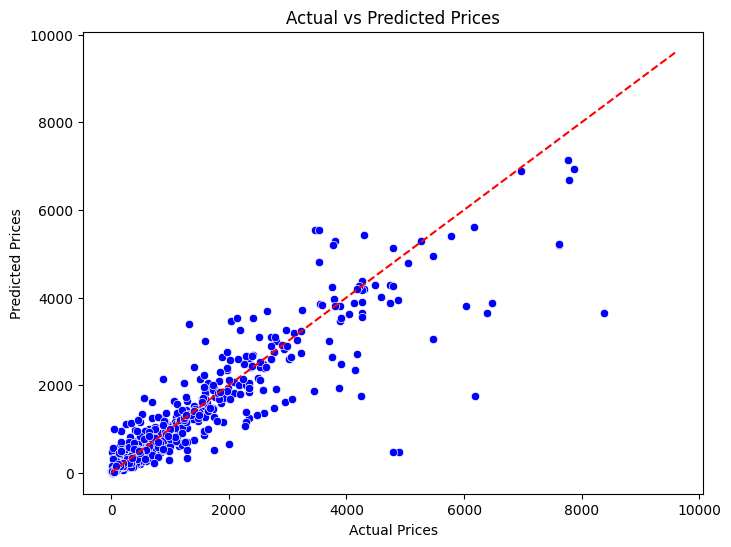

In [457]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=predictions, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()